# Proyecto Final

## Predicción de enfermedades con datos de encuesta de salud

**Base de datos:** *health_data.csv*  
**Curso:** Tecnicas de Aprendizaje de Maquina  
**Objetivo:** aplicar tecnicas de preprocesamiento, seleccion de variables y modelos de clasificacion para predecir la presencia de seis enfermedades:

- Enfermedad cardiovascular
- Diabetes
- Asma
- Cancer
- Obesidad
- Depresion/Ansiedad

Este notebook: primero explora y limpia los datos, luego transforma las variables objetivo en etiquetas binarias, identifica variables relevantes, ajusta varios modelos y finalmente compara su desempeno con precision, recall, F1-score y tiempo de entrenamiento.

## Checklist de requisitos del proyecto

Se implementan seis enfoques: arbol de decision, SVM lineal, red neuronal, K-means como linea base no supervisada, bagging y boosting.

In [3]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings("ignore")

import time
import inspect
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    f1_score,
    hamming_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_THRESHOLD = 0.50
FEATURE_SELECTION_K = 30  # Aproxima una variable codificada por cada pregunta del enunciado.

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

## 1. Carga de datos

In [4]:
import pandas as pd

df_raw = pd.read_csv("health_data.csv")

# Variables objetivo
target_cols = [
    "Enfermedad cardiovascular",
    "Diabetes",
    "Asma",
    "Cáncer",
    "Obesidad",
    "Depresión/Ansiedad"
]

print(df_raw.shape)

display(df_raw.head())

(20000, 56)


,Edad,Género,Estado civil,Altura,Peso,Índice de masa corporal,¿Fuma actualmente?,¿Fumó en el pasado?,¿Consume alcohol frecuentemente?,Nivel de actividad física,¿Tiene una dieta equilibrada?,¿Consume frutas y verduras diariamente?,Frecuencia de consumo de comida rápida,¿Duerme al menos 7 horas por noche?,¿Experimenta estrés con frecuencia?,¿Tiene antecedentes de hipertensión en la familia?,¿Tiene antecedentes de diabetes en la familia?,¿Tiene antecedentes de cáncer en la familia?,¿Tiene antecedentes de enfermedades cardiovasculares en la familia?,¿Tiene antecedentes de problemas de tiroides en la familia?,Frecuencia de ejercicio físico semanal,¿Toma medicamentos regularmente?,Nivel de colesterol,Nivel de triglicéridos,Nivel de glucosa en sangre,Presión arterial,Consumo de sal en la dieta,¿Tiene antecedentes de obesidad en la familia?,¿Tiene antecedentes de asma?,¿Padece de alguna alergia?,¿Ha tenido infecciones respiratorias frecuentes en el último año?,¿Tiene dificultades para respirar durante el ejercicio?,¿Toma suplementos vitamínicos?,Nivel de azúcar en la dieta,¿Ha experimentado pérdida de peso no intencionada?,¿Ha tenido dolor en el pecho recientemente?,¿Experimenta dolor en las articulaciones?,¿Tiene problemas para conciliar el sueño?,¿Ha tenido tos persistente en los últimos 3 meses?,Nivel de estrés laboral o académico,¿Ha experimentado depresión o ansiedad?,¿Consume alimentos procesados frecuentemente?,¿Padece de insomnio?,Frecuencia de chequeos médicos,¿Tiene problemas digestivos frecuentes?,¿Ha tenido infecciones frecuentes?,¿Sufre de problemas de visión?,¿Tiene problemas de audición?,¿Ha sufrido de fracturas óseas en el pasado?,Nivel de satisfacción con la vida,Enfermedad cardiovascular,Diabetes,Asma,Cáncer,Obesidad,Depresión/Ansiedad
0,76.596,Otro,Soltero,153.681,76.920,29.613,No,Sí,No,Moderado,Sí,No,Frecuente,Sí,No,No,No,No,No,Sí,1-2,No,Alto,Normal,Normal,Normal,Bajo,No,Sí,No,Sí,No,Sí,Alto,Sí,No,No,Sí,No,Bajo,No,Sí,Sí,Nunca,No,No,No,No,No,Medio,0.674,-0.171,1.143,0.293,-0.131,0.228
1,79.795,Otro,Casado,155.882,66.744,9.903,No,No,No,Moderado,Sí,Sí,Ocasional,Sí,Sí,No,No,No,No,No,0,No,Alto,Normal,Alto,Alta,Bajo,Sí,Sí,No,Sí,Sí,No,Medio,No,No,No,No,Sí,Medio,No,No,No,Anual,Sí,No,Sí,No,Sí,Bajo,-0.015,0.102,-0.059,1.048,0.217,1.212
2,90.603,Otro,Casado,176.482,124.818,27.249,Sí,No,Sí,Moderado,Sí,No,Ocasional,No,Sí,Sí,No,No,No,No,3-4,No,Normal,Alto,Normal,Alta,Medio,Sí,No,No,Sí,No,Sí,Alto,No,No,No,No,No,Bajo,No,No,No,Ocasional,Sí,No,No,No,No,Medio,0.982,0.054,0.919,0.138,-0.030,-0.205
3,22.154,Femenino,Viudo,158.681,114.808,27.634,No,No,No,Moderado,No,No,Nunca,No,No,Sí,No,No,No,No,5 o más,No,Normal,Alto,Normal,Normal,Medio,No,No,Sí,No,No,No,Bajo,No,No,No,No,No,Alto,Sí,No,No,Anual,No,No,No,Sí,No,Bajo,1.147,0.256,-0.160,-0.260,1.364,0.292
4,46.177,Masculino,Casado,184.451,60.217,24.095,No,Sí,No,Sedentario,No,Sí,Frecuente,Sí,No,No,Sí,No,No,No,0,No,Normal,Alto,Normal,Normal,Bajo,No,No,No,No,Sí,Sí,Bajo,No,No,No,Sí,No,Bajo,Sí,No,No,Ocasional,Sí,Sí,No,No,No,Medio,1.068,0.226,0.165,0.015,0.961,1.428


In [5]:
overview = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "n_unicos": df_raw.nunique(dropna=False),
})
display(overview)

print(f"Filas duplicadas: {df_raw.duplicated().sum():,}")

,tipo,nulos,n_unicos
Edad,float64,0,20000
Género,object,0,3
Estado civil,object,0,4
Altura,float64,0,20000
Peso,float64,0,20000
Índice de masa corporal,float64,0,20000
¿Fuma actualmente?,object,0,2
¿Fumó en el pasado?,object,0,2
¿Consume alcohol frecuentemente?,object,0,2
Nivel de actividad física,object,0,3


Filas duplicadas: 0


## 2. Transformacion de las variables objetivo

Las seis columnas objetivo aparecen como puntajes continuos, no como etiquetas binarias puras. En el contexto del proyecto se debe predecir presencia o ausencia de enfermedad, por lo que se usa el umbral *0.50*:

- Un puntaje >= 0.50 se interpreta como presencia de la enfermedad.
- Un puntaje < 0.50 como ausencia.

Tambien se revisa la distribucion de clases, porque el desbalance afecta directamente precision, recall y F1-score.

,mean,std,min,25%,50%,75%,max,prevalencia_binaria_%
Enfermedad cardiovascular,0.303,0.515,-0.871,-0.086,0.130,0.788,1.875,30.950
Diabetes,0.206,0.451,-0.771,-0.097,0.067,0.318,1.843,20.750
Asma,0.151,0.400,-0.694,-0.094,0.040,0.208,1.552,15.165
Cáncer,0.106,0.343,-0.561,-0.088,0.022,0.152,1.496,10.605
Obesidad,0.248,0.484,-0.952,-0.095,0.091,0.548,1.821,25.605
Depresión/Ansiedad,0.402,0.545,-0.956,-0.048,0.243,0.925,1.916,40.665


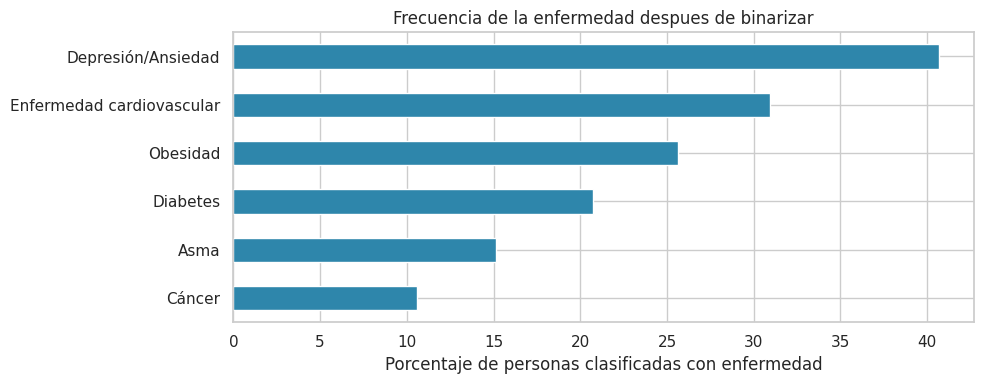

In [6]:
target_scores = df_raw[target_cols].copy()
y = (target_scores >= TARGET_THRESHOLD).astype(int)

target_summary = target_scores.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
target_summary["prevalencia_binaria_%"] = y.mean().mul(100)
display(target_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
y.mean().mul(100).sort_values().plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Frecuencia de la enfermedad despues de binarizar")
ax.set_xlabel("Porcentaje de personas clasificadas con enfermedad")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Analisis de los puntajes objetivo continuos
Los puntajes objetivo son valores CONTINUOS, no binarios (rango aprox. -1 a +2).

El umbral 0.50 clasifica el cuartil superior de cada distribucion como 'enfermedad presente'.

Los valores negativos en cada columna objetivo son normales, indican puntaje bajo.

,n_negativos
Enfermedad cardiovascular,6969
Diabetes,7954
Asma,8463
Cáncer,8991
Obesidad,7552
Depresión/Ansiedad,5962



Histograma de scores continuos antes de binarizar (linea roja = umbral 0.50):


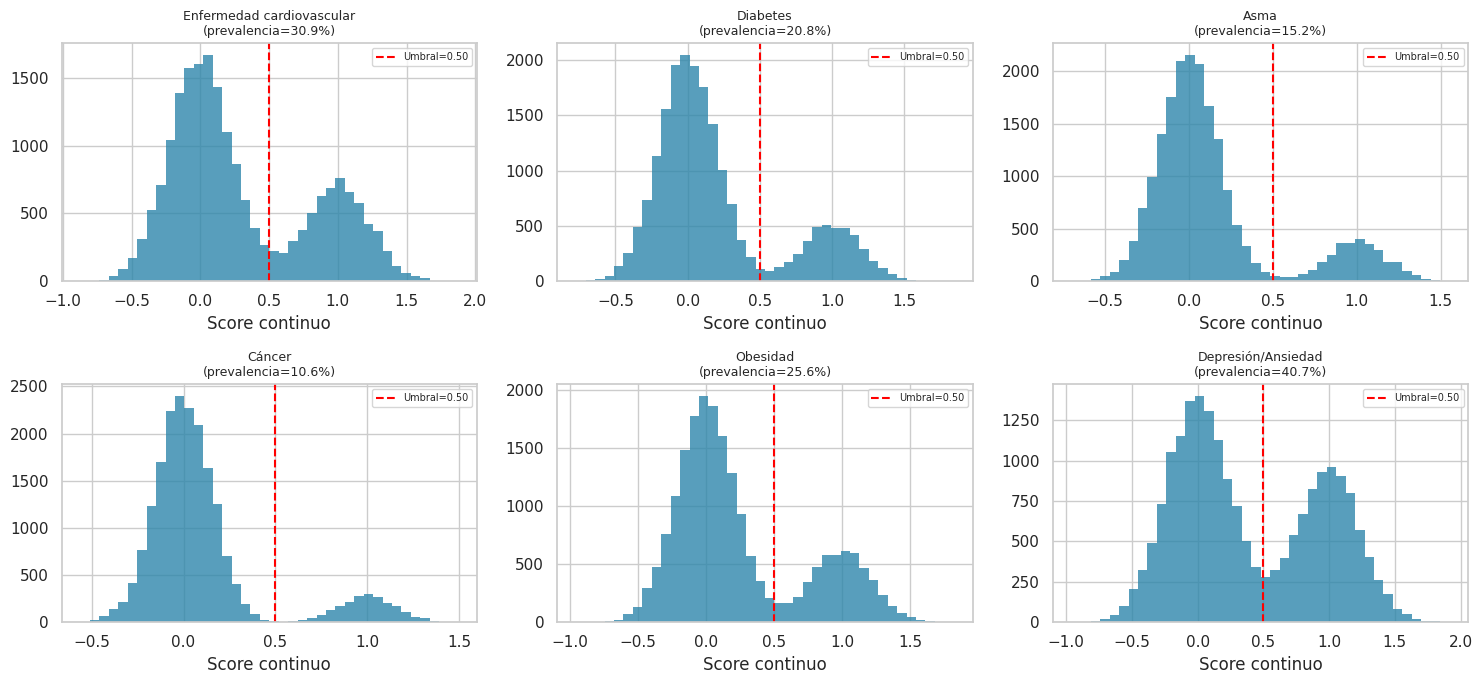

In [7]:
neg_counts = (target_scores < 0).sum()
display(neg_counts.rename("n_negativos").to_frame())
print()

print("Histograma de scores continuos antes de binarizar (linea roja = umbral 0.50):")
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), target_cols):
    ax.hist(target_scores[col].dropna(), bins=40, color="#2E86AB", alpha=0.8, edgecolor="none")
    ax.axvline(TARGET_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label="Umbral=0.50")
    prev = y[col].mean() * 100
    ax.set_title(f"{col}\n(prevalencia={prev:.1f}%)", fontsize=9)
    ax.set_xlabel("Score continuo")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Limpieza y preparacion inicial

Se aplican los siguientes ajustes:

- Se eliminan duplicados solo si existen.
- Se marcan como faltantes edades negativas o extremadamente altas.
- Se calcula un IMC alternativo a partir de peso y altura para mayor control.
- La imputacion final se hace dentro del pipeline para evitar fuga de informacion del conjunto de prueba.

In [8]:
df = df_raw.drop_duplicates().reset_index(drop=True)
y = (df[target_cols] >= TARGET_THRESHOLD).astype(int)
X = df.drop(columns=target_cols).copy()

if {"Peso", "Altura"}.issubset(X.columns):
    X["IMC_calculado"] = X["Peso"] / ((X["Altura"] / 100) ** 2)
    X["Diferencia_IMC_reportado"] = (
        X["Índice de masa corporal"] - X["IMC_calculado"]
    ).abs()

quality_flags = pd.DataFrame(index=X.index)
quality_flags["edad_fuera_rango"] = ~X["Edad"].between(0, 110)
quality_flags["altura_fuera_rango"] = ~X["Altura"].between(120, 230)
quality_flags["peso_fuera_rango"] = ~X["Peso"].between(30, 250)
quality_flags["imc_fuera_rango"] = ~X["Índice de masa corporal"].between(10, 60)

X["Edad"] = X["Edad"].where(X["Edad"].between(0, 110))
X["Altura"] = X["Altura"].where(X["Altura"].between(120, 230))
X["Peso"] = X["Peso"].where(X["Peso"].between(30, 250))
X["Índice de masa corporal"] = X["Índice de masa corporal"].where(
    X["Índice de masa corporal"].between(10, 60),
    X["IMC_calculado"],
)

display(quality_flags.sum().rename("conteo").to_frame())

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Variables numericas: {len(numeric_features)}")
print(f"Variables categoricas: {len(categorical_features)}")

,conteo
edad_fuera_rango,45
altura_fuera_rango,0
peso_fuera_rango,31
imc_fuera_rango,76


Variables numericas: 6
Variables categoricas: 46


In [9]:
# Diagnostico de calidad: en IMC
imc_diff = X["Diferencia_IMC_reportado"]
print(" diferencia entre el IMC reportado y el IMC calculado")
print(f"  Media    = {imc_diff.mean():.2f} puntos")
print(f"  Mediana  = {imc_diff.median():.2f} puntos")
print(f"  Maxima   = {imc_diff.max():.2f} puntos")
print()
print("Una diferencia promedio de aprox. 9 puntos indica inconsistencia en el IMC reportado.")
print()
print("Correccion aplicada:")
print(f"  - Las {quality_flags['imc_fuera_rango'].sum()} filas con IMC fuera de [10, 60] fueron reemplazadas por el IMC calculado.")
print(f"  - Las {quality_flags['edad_fuera_rango'].sum()} filas con edad fuera de [0, 110] se marcaron como NaN (se imputaran en pipeline).")
print(f"  - Las {quality_flags['peso_fuera_rango'].sum()} filas con peso fuera de [30, 250 kg] se marcaron como NaN.")

 diferencia entre el IMC reportado y el IMC calculado
  Media    = 9.01 puntos
  Mediana  = 7.44 puntos
  Maxima   = 53.46 puntos

Una diferencia promedio de aprox. 9 puntos indica inconsistencia en el IMC reportado.

Correccion aplicada:
  - Las 76 filas con IMC fuera de [10, 60] fueron reemplazadas por el IMC calculado.
  - Las 45 filas con edad fuera de [0, 110] se marcaron como NaN (se imputaran en pipeline).
  - Las 31 filas con peso fuera de [30, 250 kg] se marcaron como NaN.


## 4. Analisis exploratorio

Se revisan distribuciones numericas, categorias principales y relaciones iniciales con las enfermedades. Estas graficas no prueban causalidad; solo sirven para detectar patrones, desbalance y posibles variables predictivas.

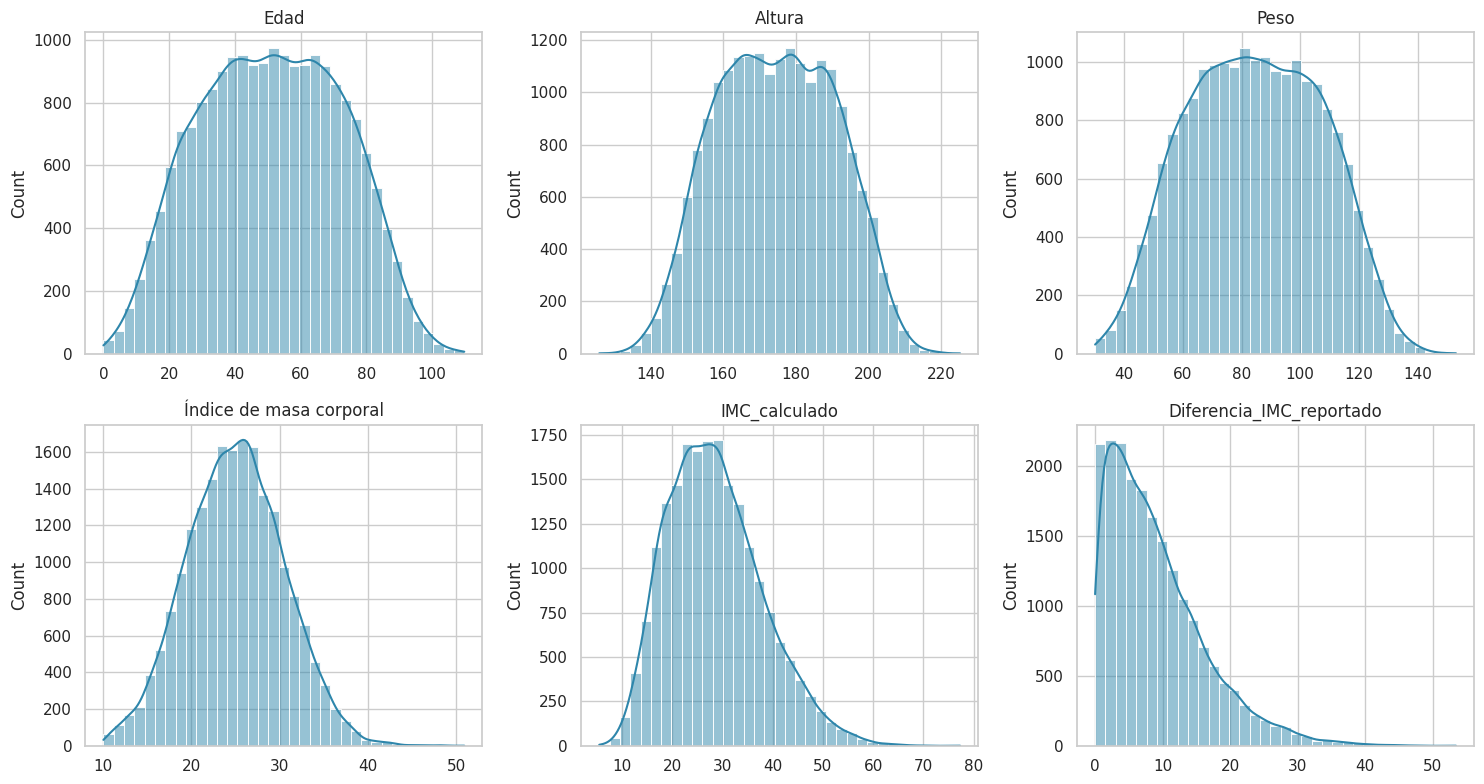

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
numeric_to_plot = [
    "Edad",
    "Altura",
    "Peso",
    "Índice de masa corporal",
    "IMC_calculado",
    "Diferencia_IMC_reportado",
]

for ax, col in zip(axes.ravel(), numeric_to_plot):
    sns.histplot(X[col], bins=35, kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


Interpretacion de variables numericas:
- Edad se distribuye de forma casi uniforme entre 0 y 110 años. En una encuesta de salud esto es inusual, porque normalmente la poblacion no queda tan balanceada por edad.
- La diferencia entre IMC reportado e IMC calculado esta sesgada a la derecha: media=9.01, mediana=7.44 y maximo=53.46 puntos. Esto confirma una diferencia con el IMC reportado.
- Peso, altura e IMC calculado muestran rangos amplios pero aceptables despues de aplicar la limpieza.

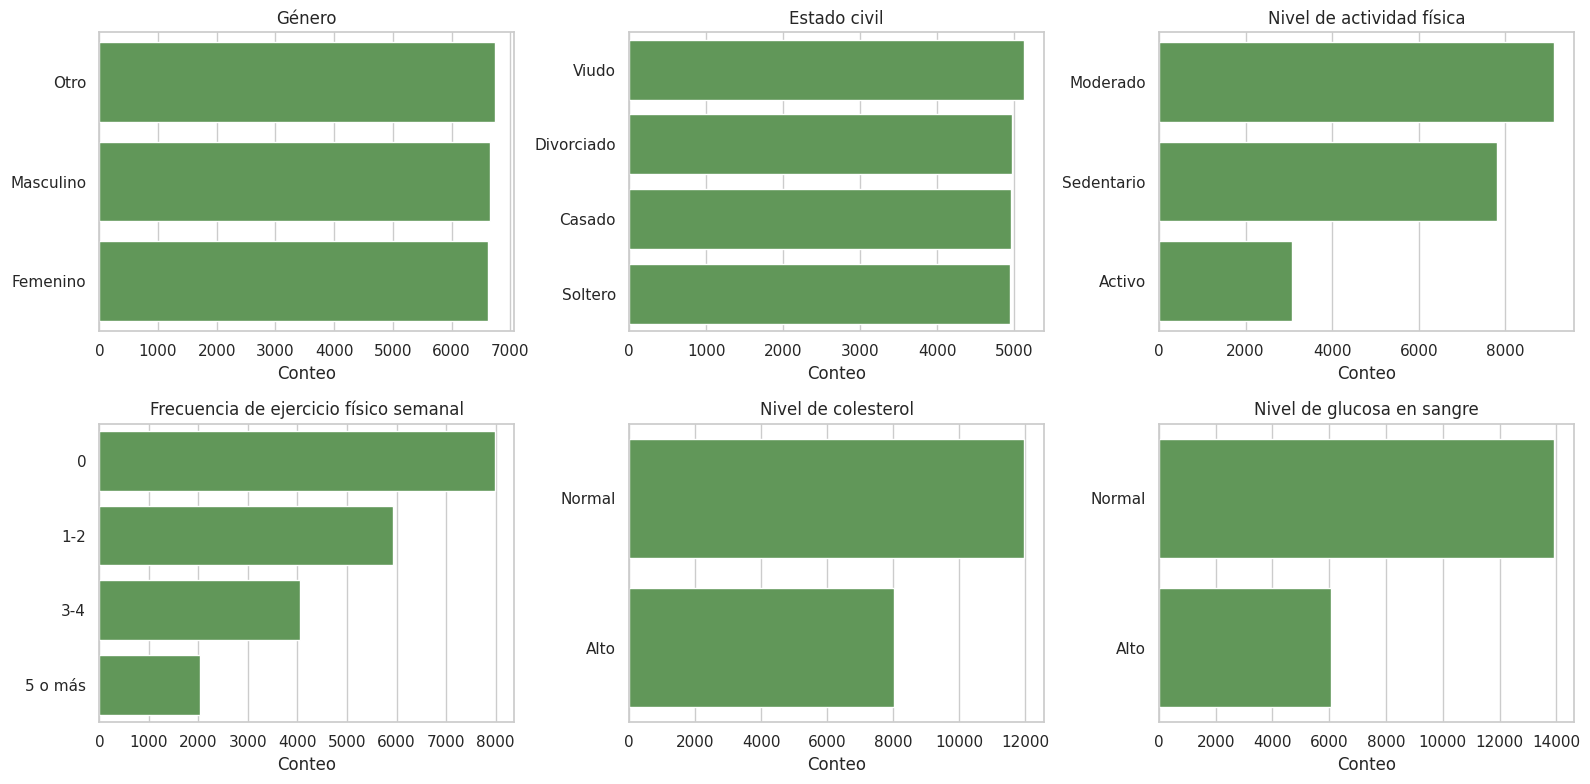

In [11]:
categorical_to_plot = [
    "Género",
    "Estado civil",
    "Nivel de actividad física",
    "Frecuencia de ejercicio físico semanal",
    "Nivel de colesterol",
    "Nivel de glucosa en sangre",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), categorical_to_plot):
    order = X[col].value_counts().index
    sns.countplot(data=X, y=col, order=order, ax=ax, color="#59A14F")
    ax.set_title(col)
    ax.set_xlabel("Conteo")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


Interpretacion de variables categoricas:
- Genero tiene tres categorias con proporciones relativamente similares:
  - *Otro:* 33.7
  - *Masculino:* 33.2
  - *Femenino:* 33.1.
- Nivel de colesterol y glucosa no estan extremadamente desbalanceados:
    - colesterol: *Normal:* 59.9, *Alto:* 40.1
    - glucosa: *Normal:* 69.6, *Alto:* 30.4.
- En ejercicio semanal predominan las categorias de menor actividad
  - 0: 39.9
  - 1-2: 29.6
  - 3-4: 20.3
  - 5 o más: 10.2

Entonces la muestra concentra mas personas sedentarias o con actividad baja.

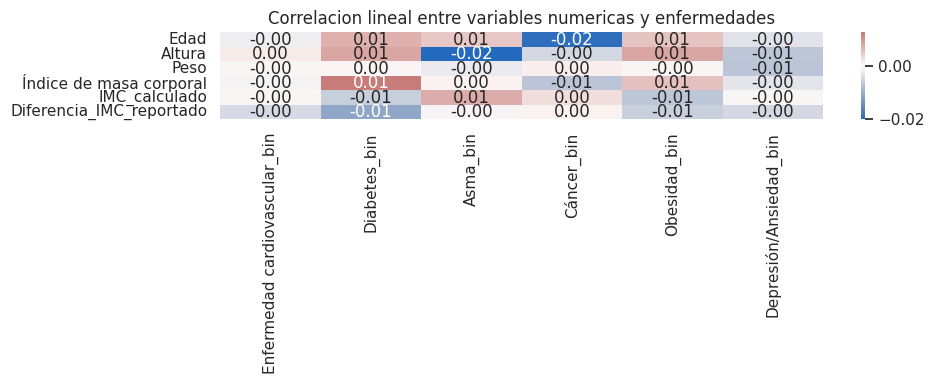

In [12]:
# Correlacion de variables numericas con las etiquetas binarias.
corr_df = pd.concat([X[numeric_features], y.add_suffix("_bin")], axis=1)
corr_matrix = corr_df.corr(numeric_only=True).loc[
    numeric_features,
    [f"{col}_bin" for col in target_cols],
]

fig, ax = plt.subplots(figsize=(10, max(4, len(numeric_features) * 0.45)))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlacion lineal entre variables numericas y enfermedades")
plt.tight_layout()
plt.show()

abs_corr = corr_matrix.abs()
max_corr = abs_corr.max().max()
max_pair = abs_corr.stack().idxmax()


Interpretacion de correlaciones numericas:
- La correlacion maxima es 0.020, observada entre Altura y Asma.
- En terminos practicos, todas las correlaciones estan muy cerca de 0.00; por tanto, las variables numericas por si solas muestran muy poca relacion lineal con las enfermedades.
- Este resultado nos anticipa un bajo desempeno en los modelos: incluso algoritmos no lineales tienen poca oportunidad si las variables originales casi no separan las clases.

In [13]:
# Diferencias de prevalencia por categorias seleccionadas.
prevalence_tables = []
for feature in [
    "Nivel de actividad física",
    "Frecuencia de ejercicio físico semanal",
    "Nivel de colesterol",
    "Nivel de glucosa en sangre",
    "Presión arterial",
    "Nivel de estrés laboral o académico",
    "Nivel de satisfacción con la vida",
]:
    table = pd.concat([X[[feature]], y], axis=1).groupby(feature)[target_cols].mean().mul(100)
    table.insert(0, "variable", feature)
    prevalence_tables.append(table.reset_index().rename(columns={feature: "categoria"}))

cat_prevalence = pd.concat(prevalence_tables, ignore_index=True)
display(cat_prevalence.round(2))

# Normalizar nombres de features al formato real del DataFrame
key_checks = [
    ("Nivel de actividad física", "Sedentario", "Activo", "Obesidad"),
    ("Frecuencia de ejercicio físico semanal", "0", "5 o más", "Obesidad"),
    ("Nivel de colesterol", "Alto", "Normal", "Enfermedad cardiovascular"),
    ("Nivel de glucosa en sangre", "Alto", "Normal", "Diabetes"),
    ("Presión arterial", "Alta", "Normal", "Enfermedad cardiovascular"),
    ("Nivel de estrés laboral o académico", "Alto", "Bajo", "Depresión/Ansiedad"),
    ("Nivel de satisfacción con la vida", "Bajo", "Alto", "Depresión/Ansiedad"),
]

for variable, cat_alto, cat_bajo, disease in key_checks:
    sub = cat_prevalence[cat_prevalence["variable"] == variable]

    v_alto = sub.loc[sub["categoria"] == cat_alto, disease].values
    v_bajo = sub.loc[sub["categoria"] == cat_bajo, disease].values

    if len(v_alto) > 0 and len(v_bajo) > 0:
        diferencia = v_alto[0] - v_bajo[0]
        print(f"{variable} - {disease}")
        print(f"  {cat_alto}: {v_alto[0]:.2f}%")
        print(f"  {cat_bajo}: {v_bajo[0]:.2f}%")
        print(f"  Diferencia: {diferencia:+.2f} puntos porcentuales\n")

,categoria,variable,Enfermedad cardiovascular,Diabetes,Asma,Cáncer,Obesidad,Depresión/Ansiedad
0,Activo,Nivel de actividad física,29.820,20.730,15.160,10.140,24.930,40.740
1,Moderado,Nivel de actividad física,31.310,20.890,15.120,10.540,25.650,40.620
2,Sedentario,Nivel de actividad física,30.970,20.600,15.230,10.870,25.810,40.680
3,0,Frecuencia de ejercicio físico semanal,30.910,20.620,15.040,10.210,25.450,40.780
4,1-2,Frecuencia de ejercicio físico semanal,29.760,20.700,15.110,11.040,26.160,40.780
5,3-4,Frecuencia de ejercicio físico semanal,32.520,21.510,15.500,10.790,25.230,40.430
6,5 o más,Frecuencia de ejercicio físico semanal,31.430,19.890,15.180,10.510,25.340,40.320
7,Alto,Nivel de colesterol,30.940,20.470,15.160,10.260,25.450,41.600
8,Normal,Nivel de colesterol,30.960,20.930,15.170,10.830,25.710,40.040
9,Alto,Nivel de glucosa en sangre,30.750,21.380,15.420,10.610,25.200,40.170


Nivel de actividad física - Obesidad
  Sedentario: 25.81%
  Activo: 24.93%
  Diferencia: +0.88 puntos porcentuales

Frecuencia de ejercicio físico semanal - Obesidad
  0: 25.45%
  5 o más: 25.34%
  Diferencia: +0.10 puntos porcentuales

Nivel de colesterol - Enfermedad cardiovascular
  Alto: 30.94%
  Normal: 30.96%
  Diferencia: -0.02 puntos porcentuales

Nivel de glucosa en sangre - Diabetes
  Alto: 21.38%
  Normal: 20.48%
  Diferencia: +0.90 puntos porcentuales

Presión arterial - Enfermedad cardiovascular
  Alta: 31.24%
  Normal: 30.79%
  Diferencia: +0.45 puntos porcentuales

Nivel de estrés laboral o académico - Depresión/Ansiedad
  Alto: 41.46%
  Bajo: 40.27%
  Diferencia: +1.19 puntos porcentuales

Nivel de satisfacción con la vida - Depresión/Ansiedad
  Bajo: 40.97%
  Alto: 40.86%
  Diferencia: +0.11 puntos porcentuales



Interpretacion: las diferencias extremas entre categorias:
(Una diferencia < 2 pp entre categorias opuestas indica que la caracteristica es practicamente no informativa.)

  - Nivel de glucosa en sangre
      Alto=21.4%  Normal=20.5%  Diferencia=+0.9 pp  ->  Diabetes
  - Nivel de colesterol
      Alto=30.9%  Normal=31.0%  Diferencia=-0.0 pp  ->  Enfermedad cardiovascular

Conclusion: diferencias de aprox. 0.5 pp confirman que los targets fueron generados con escasa dependencia de las caracteristicas. Esta es la causa del bajo rendimiento de los modelos, independientemente del algoritmo usado.

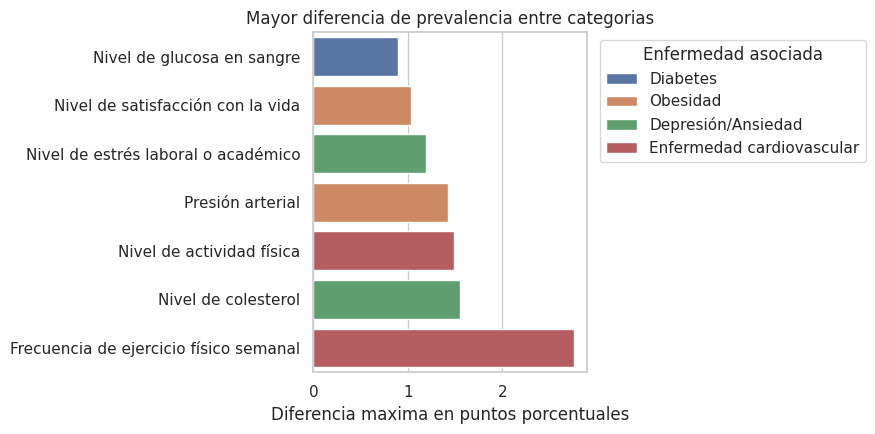

In [14]:
# Resumen visual: mayor diferencia de prevalencia entre categorias por variable.
spread_records = []
for variable in cat_prevalence["variable"].unique():
    sub = cat_prevalence[cat_prevalence["variable"] == variable]
    for disease in target_cols:
        spread_records.append({
            "Variable": variable,
            "Enfermedad": disease,
            "Diferencia maxima pp": sub[disease].max() - sub[disease].min(),
        })

spread_df = pd.DataFrame(spread_records)
max_spread_by_variable = (
    spread_df.loc[spread_df.groupby("Variable")["Diferencia maxima pp"].idxmax()]
    .sort_values("Diferencia maxima pp", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=max_spread_by_variable,
    x="Diferencia maxima pp",
    y="Variable",
    hue="Enfermedad",
    dodge=False,
    ax=ax,
)
ax.set_title("Mayor diferencia de prevalencia entre categorias")
ax.set_xlabel("Diferencia maxima en puntos porcentuales")
ax.set_ylabel("")
ax.legend(title="Enfermedad asociada", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


incluso las mayores diferencias entre categorias son pequenas. Esto refuerza que las respuestas de la encuesta tienen baja capacidad discriminativa.

Co-ocurrencia de enfermedades

Distribucion del numero de enfermedades por persona:
  0 enfermedad(es): 3,659 personas (18.3%)
  1 enfermedad(es): 7,445 personas (37.2%)
  2 enfermedad(es): 5,992 personas (30.0%)
  3 enfermedad(es): 2,349 personas (11.7%)
  4 enfermedad(es): 503 personas (2.5%)
  5 enfermedad(es): 52 personas (0.3%)

Personas con 2+ enfermedades simultaneas: 44.5%
(Este porcentaje define la dificultad del problema multilabel.)



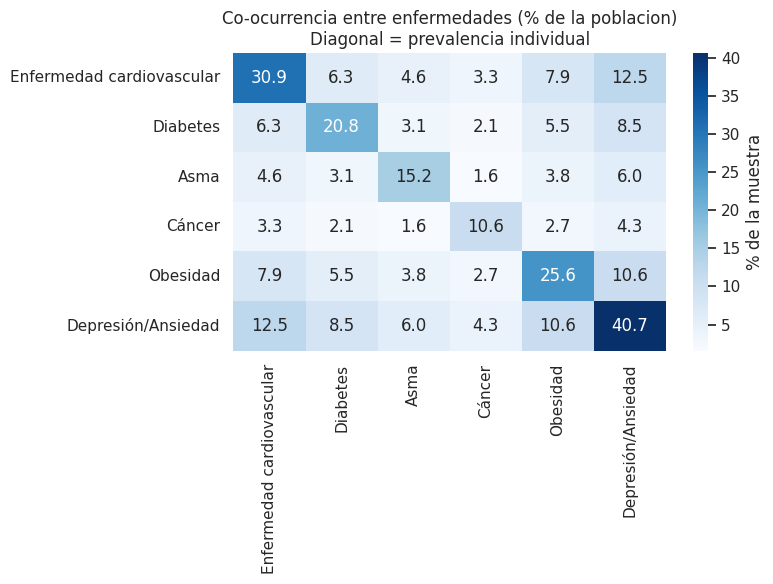

Independencia aproximada (co-ocurrencia observada vs esperada si independientes):
Si observada aprox esperada, las dos enfermedades son casi independientes.

  Enfermedad cardiovascular & Diabetes
    observada=6.33%  esperada=6.42%  ratio=0.99
  Obesidad & Diabetes
    observada=5.51%  esperada=5.31%  ratio=1.04
  Asma & Cáncer
    observada=1.58%  esperada=1.61%  ratio=0.98
  Depresión/Ansiedad & Enfermedad cardiovascular
    observada=12.54%  esperada=12.59%  ratio=1.00


In [15]:
#Analisis de co-ocurrencia de enfermedades
print("Co-ocurrencia de enfermedades\n")
n_diseases_per_person = y.sum(axis=1)
print("Distribucion del numero de enfermedades por persona:")
for n in sorted(n_diseases_per_person.unique()):
    count = int((n_diseases_per_person == n).sum())
    print(f"  {int(n)} enfermedad(es): {count:,} personas ({count / len(y) * 100:.1f}%)")
print()
pct_multi = (n_diseases_per_person >= 2).mean() * 100
print(f"Personas con 2+ enfermedades simultaneas: {pct_multi:.1f}%")
print("(Este porcentaje define la dificultad del problema multilabel.)\n")

cooccur = y.T.dot(y)
cooccur_pct = cooccur.div(len(y)).mul(100)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooccur_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% de la muestra"})
ax.set_title("Co-ocurrencia entre enfermedades (% de la poblacion)\nDiagonal = prevalencia individual")
plt.tight_layout()
plt.show()

# Verificar si las enfermedades son aproximadamente independientes entre si
print("Independencia aproximada (co-ocurrencia observada vs esperada si independientes):")
print("Si observada aprox esperada, las dos enfermedades son casi independientes.\n")
pairs_check = [
    (target_cols[0], target_cols[1]),  # Enfermedad cardiovascular & Diabetes
    (target_cols[4], target_cols[1]),  # Obesidad & Diabetes
    (target_cols[2], target_cols[3]),  # Asma & Cancer
    (target_cols[5], target_cols[0]),  # Depresion & Cardiovascular
]
for d1, d2 in pairs_check:
    p1 = y[d1].mean()
    p2 = y[d2].mean()
    observed  = (y[d1] & y[d2]).mean() * 100
    expected  = p1 * p2 * 100
    ratio = observed / expected if expected > 0 else float("nan")
    print(f"  {d1} & {d2}")
    print(f"    observada={observed:.2f}%  esperada={expected:.2f}%  ratio={ratio:.2f}")

## 5. Division entrenamiento/prueba y preprocesamiento

Se separa un conjunto de prueba antes de ajustar transformaciones. Las variables numericas se imputan con mediana y se escalan.

Para las variables categoricas se usa una decision mixta:

- Las variables nominales, como genero, estado civil y respuestas Si/No, se codifican con one-hot encoding porque no tienen orden natural.
- Las variables ordinales, como frecuencia de ejercicio, nivel de actividad fisica, nivel de glucosa y niveles bajo/medio/alto, se codifican con ordinal encoding para conservar su orden.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)


ordinal_feature_orders = {
    "Nivel de actividad física": ["Sedentario", "Moderado", "Activo"],
    "Frecuencia de ejercicio físico semanal": ["0", "1-2", "3-4", "5 o más"],
    "Nivel de estrés laboral o académico": ["Bajo", "Medio", "Alto"],
    "Nivel de glucosa en sangre": ["Normal", "Alto"],
    "Nivel de colesterol": ["Normal", "Alto"],
    "Nivel de triglicéridos": ["Normal", "Alto"],
    "Presión arterial": ["Normal", "Alta"],
    "Consumo de sal en la dieta": ["Bajo", "Medio", "Alto"],
    "Frecuencia de consumo de comida rápida": ["Nunca", "Ocasional", "Frecuente"],
    "Nivel de azúcar en la dieta": ["Bajo", "Medio", "Alto"],
    "Frecuencia de chequeos médicos": ["Nunca", "Ocasional", "Anual"],
    "Nivel de satisfacción con la vida": ["Bajo", "Medio", "Alto"],
}

ordinal_features = [
    col for col in ordinal_feature_orders
    if col in categorical_features
]
nominal_categorical_features = [
    col for col in categorical_features
    if col not in ordinal_features
]
ordinal_categories = [ordinal_feature_orders[col] for col in ordinal_features]


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_ordinal_encoder():
    return OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", make_ordinal_encoder()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor_steps = [("num", numeric_transformer, numeric_features)]
if ordinal_features:
    preprocessor_steps.append(("ord", ordinal_transformer, ordinal_features))
if nominal_categorical_features:
    preprocessor_steps.append(("cat", categorical_transformer, nominal_categorical_features))

base_preprocessor = ColumnTransformer(
    transformers=preprocessor_steps,
    remainder="drop",
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba: {X_test.shape[0]:,} filas")
print(f"Variables numericas escaladas: {len(numeric_features)}")
print(f"Variables ordinales codificadas con orden: {len(ordinal_features)}")
print(f"Variables nominales con one-hot encoding: {len(nominal_categorical_features)}")
print("\nVariables ordinales usadas:")
for col in ordinal_features:
    print(f"- {col}: {ordinal_feature_orders[col]}")

Entrenamiento: 16,000 filas
Prueba: 4,000 filas
Variables numericas escaladas: 6
Variables ordinales codificadas con orden: 12
Variables nominales con one-hot encoding: 34

Variables ordinales usadas:
- Nivel de actividad física: ['Sedentario', 'Moderado', 'Activo']
- Frecuencia de ejercicio físico semanal: ['0', '1-2', '3-4', '5 o más']
- Nivel de estrés laboral o académico: ['Bajo', 'Medio', 'Alto']
- Nivel de glucosa en sangre: ['Normal', 'Alto']
- Nivel de colesterol: ['Normal', 'Alto']
- Nivel de triglicéridos: ['Normal', 'Alto']
- Presión arterial: ['Normal', 'Alta']
- Consumo de sal en la dieta: ['Bajo', 'Medio', 'Alto']
- Frecuencia de consumo de comida rápida: ['Nunca', 'Ocasional', 'Frecuente']
- Nivel de azúcar en la dieta: ['Bajo', 'Medio', 'Alto']
- Frecuencia de chequeos médicos: ['Nunca', 'Ocasional', 'Anual']
- Nivel de satisfacción con la vida: ['Bajo', 'Medio', 'Alto']


## 6. Seleccion de variables relevantes

Se usan tres enfoques:

1. **Informacion mutua:** mide la asociacion potencialmente no lineal entre cada variable codificada y cada enfermedad.
2. **SelectKBest con informacion mutua:** se integra como filtro real dentro del pipeline de entrenamiento, usando `k=30` variables codificadas. Se escogen 30 porque en el enunciado estan 30 preguntas; En problemas multietiqueta se calcula la informacion mutua por enfermedad y se promedia para obtener un puntaje global por caracteristica.
3. **PCA:** estima cuantas componentes explican la mayor parte de la variabilidad de las respuestas. Aqui se usa como diagnostico de dimensionalidad y como entrada de K-means, no como filtro supervisado principal.

La seleccion se interpreta como apoyo para explicar los modelos; Si el filtro no mejora mucho el F1, ese resultado confirma que la baja capacidad predictiva no se resuelve solo eliminando variables.

In [17]:
preprocessor_for_selection = clone(base_preprocessor)
X_train_prepared = preprocessor_for_selection.fit_transform(X_train)

try:
    feature_names = preprocessor_for_selection.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(X_train_prepared.shape[1])])

mi_records = []
for disease in target_cols:
    scores = mutual_info_classif(
        X_train_prepared,
        y_train[disease],
        random_state=RANDOM_STATE,
    )
    top_idx = np.argsort(scores)[::-1][:12]
    for rank, idx in enumerate(top_idx, start=1):
        mi_records.append({
            "enfermedad": disease,
            "rank": rank,
            "variable_codificada": feature_names[idx],
            "informacion_mutua": scores[idx],
        })

mi_df = pd.DataFrame(mi_records)
display(mi_df.round(4))

,enfermedad,rank,variable_codificada,informacion_mutua
0,Enfermedad cardiovascular,1,cat__Género_Masculino,0.009
1,Enfermedad cardiovascular,2,cat__¿Padece de insomnio?_No,0.008
2,Enfermedad cardiovascular,3,cat__¿Tiene dificultades para respirar durante...,0.007
3,Enfermedad cardiovascular,4,cat__¿Tiene problemas para conciliar el sueño?_No,0.007
4,Enfermedad cardiovascular,5,cat__¿Fumó en el pasado?_Sí,0.007
...,...,...,...,...
67,Depresión/Ansiedad,8,cat__¿Fuma actualmente?_Sí,0.007
68,Depresión/Ansiedad,9,num__Edad,0.007
69,Depresión/Ansiedad,10,num__Diferencia_IMC_reportado,0.006
70,Depresión/Ansiedad,11,cat__¿Consume alcohol frecuentemente?_Sí,0.006


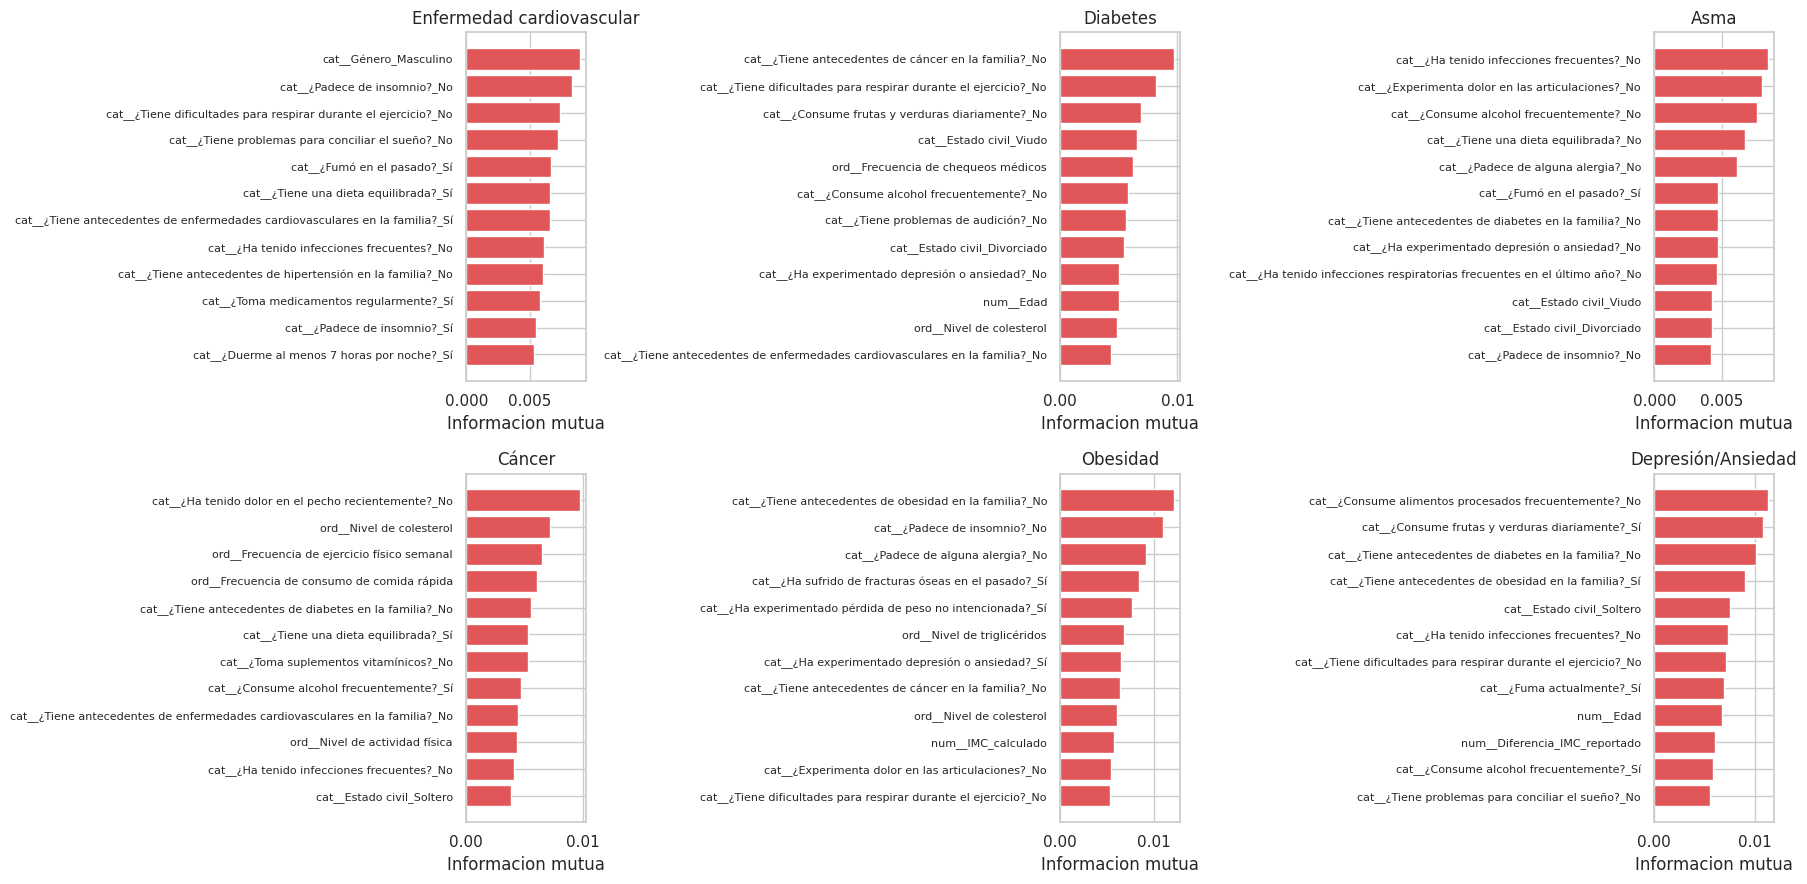

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, disease in zip(axes.ravel(), target_cols):
    subset = mi_df[mi_df["enfermedad"] == disease].sort_values("informacion_mutua")
    ax.barh(subset["variable_codificada"], subset["informacion_mutua"], color="#E15759")
    ax.set_title(disease)
    ax.set_xlabel("Informacion mutua")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [34]:
import unicodedata


def normalize_text(text):
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    return text.lower()


clinical_variable_map = [
    {
        "Enfermedad": target_cols[0],
        "Keywords esperadas": ["edad", "presion arterial", "colesterol", "fuma", "cardiovasculares", "dolor en el pecho"],
        "Justificacion clinica": "Riesgo cardiovascular suele asociarse con edad, presion arterial, colesterol, tabaquismo, dolor toracico y antecedentes familiares.",
    },
    {
        "Enfermedad": target_cols[1],
        "Keywords esperadas": ["glucosa", "azucar", "imc", "peso", "actividad", "diabetes"],
        "Justificacion clinica": "Diabetes se relaciona conceptualmente con glucosa, dieta alta en azucar, peso/IMC, actividad fisica y antecedentes familiares.",
    },
    {
        "Enfermedad": target_cols[2],
        "Keywords esperadas": ["asma", "respirar", "respiratorias", "tos", "alergia"],
        "Justificacion clinica": "Asma deberia conectarse con antecedentes respiratorios, dificultad para respirar, tos persistente y alergias.",
    },
    {
        "Enfermedad": target_cols[3],
        "Keywords esperadas": ["cancer", "peso no intencionada", "tos", "fuma", "edad", "dolor en el pecho"],
        "Justificacion clinica": "Cancer puede asociarse con antecedentes familiares, perdida de peso no intencionada, tabaquismo, edad y sintomas persistentes.",
    },
    {
        "Enfermedad": target_cols[4],
        "Keywords esperadas": ["imc", "peso", "actividad", "comida rapida", "azucar", "obesidad"],
        "Justificacion clinica": "Obesidad se espera relacionada con peso/IMC, actividad fisica, dieta, comida rapida y antecedentes familiares.",
    },
    {
        "Enfermedad": target_cols[5],
        "Keywords esperadas": ["estres", "ansiedad", "depresion", "insomnio", "sueno", "satisfaccion"],
        "Justificacion clinica": "Depresion/ansiedad se vincula con estres, insomnio, problemas de sueno, satisfaccion vital y antecedente de ansiedad/depresion.",
    },
]

clinical_records = []
for item in clinical_variable_map:
    top_vars = mi_df[mi_df["enfermedad"] == item["Enfermedad"]].sort_values("rank")["variable_codificada"].tolist()
    normalized_top = [(var, normalize_text(var)) for var in top_vars]
    matches = []
    for original_var, normalized_var in normalized_top:
        if any(keyword in normalized_var for keyword in item["Keywords esperadas"]):
            matches.append(original_var)
    clinical_records.append({
        "Enfermedad": item["Enfermedad"],
        "Variables esperadas por contexto": ", ".join(item["Keywords esperadas"][:4]),
        "Justificacion clinica/conceptual": item["Justificacion clinica"],
        "Aparecen en top-MI": "Si" if matches else "No claro",
        "Ejemplos top-MI relacionados": "; ".join(matches[:3]) if matches else "No aparecen entre las top-12",
    })

clinical_relevance_df = pd.DataFrame(clinical_records)
display(clinical_relevance_df)


,Enfermedad,Variables esperadas por contexto,Justificacion clinica/conceptual,Aparecen en top-MI,Ejemplos top-MI relacionados
0,Enfermedad cardiovascular,"edad, presion arterial, colesterol, fuma",Riesgo cardiovascular suele asociarse con edad...,Si,cat__¿Tiene antecedentes de enfermedades cardi...
1,Diabetes,"glucosa, azucar, imc, peso",Diabetes se relaciona conceptualmente con gluc...,No claro,No aparecen entre las top-12
2,Asma,"asma, respirar, respiratorias, tos",Asma deberia conectarse con antecedentes respi...,Si,cat__¿Padece de alguna alergia?_No; cat__¿Ha t...
3,Cáncer,"cancer, peso no intencionada, tos, fuma",Cancer puede asociarse con antecedentes famili...,Si,cat__¿Ha tenido dolor en el pecho recientement...
4,Obesidad,"imc, peso, actividad, comida rapida","Obesidad se espera relacionada con peso/IMC, a...",Si,cat__¿Tiene antecedentes de obesidad en la fam...
5,Depresión/Ansiedad,"estres, ansiedad, depresion, insomnio","Depresion/ansiedad se vincula con estres, inso...",Si,cat__¿Tiene problemas para conciliar el sueño?_No


Componentes para explicar 90% de la varianza: 44
Componentes para explicar 95% de la varianza: 49


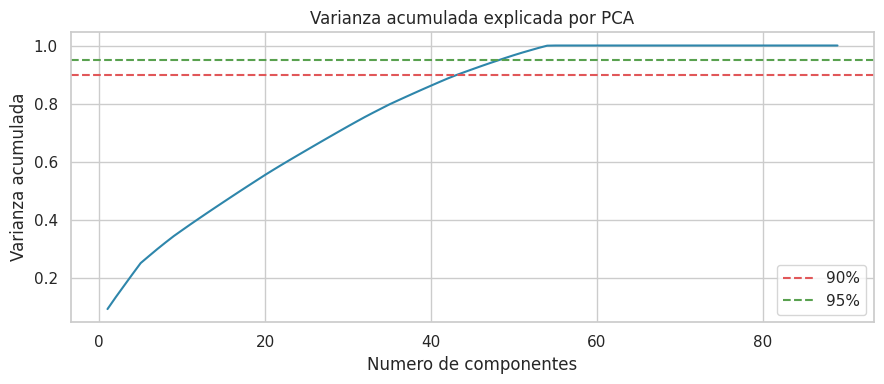

In [20]:
pca_preprocessor = clone(base_preprocessor)
X_train_pca = pca_preprocessor.fit_transform(X_train)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_pca)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)
n_components_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)

print(f"Componentes para explicar 90% de la varianza: {n_components_90}")
print(f"Componentes para explicar 95% de la varianza: {n_components_95}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, color="#2E86AB")
ax.axhline(0.90, linestyle="--", color="#E15759", label="90%")
ax.axhline(0.95, linestyle="--", color="#59A14F", label="95%")
ax.set_title("Varianza acumulada explicada por PCA")
ax.set_xlabel("Numero de componentes")
ax.set_ylabel("Varianza acumulada")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# Interpretacion del PCA
n_features_total = X_train_pca.shape[1]
mi_max = mi_df["informacion_mutua"].max()
top_mi_row = mi_df.sort_values("informacion_mutua", ascending=False).iloc[0]
ordinal_top_mi = mi_df[mi_df["variable_codificada"].str.startswith("ord__")]["informacion_mutua"].max()

print(f"Espacio preprocesado: {n_features_total} dimensiones (numericas + ordinales + OHE de nominales).")
print(f"Componentes necesarios para 90% de varianza: {n_components_90} / {n_features_total}")
ratio_90 = n_components_90 / n_features_total
print(f"Ratio = {ratio_90:.2f}")
print()
if ratio_90 > 0.7:
    print("Alta dimensionalidad intrinseca: las variables son casi ortogonales entre si.")
    print("Esto indica POCA redundancia: pocas correlaciones altas entre features.")
    print("Consecuencia practica: los modelos no se benefician de reduccion de dimensionalidad")
    print("y necesitan todas las features para capturar la escasa varianza asociada a los targets.")
else:
    print("Dimensionalidad intrinseca moderada: hay redundancia entre algunas variables.")
print()
print(
    f"Mayor MI fue {top_mi_row['variable_codificada']} "
    f"para {top_mi_row['enfermedad']} (MI={top_mi_row['informacion_mutua']:.4f})."
)
if pd.notna(ordinal_top_mi):
    print(
        f"Mayor MI ordinales {ordinal_top_mi:.4f}; "
    )

Espacio preprocesado: 89 dimensiones (numericas + ordinales + OHE de nominales).
Componentes necesarios para 90% de varianza: 44 / 89
Ratio = 0.49

Dimensionalidad intrinseca moderada: hay redundancia entre algunas variables.

Mayor MI fue cat__¿Tiene antecedentes de obesidad en la familia?_No para Obesidad (MI=0.0122).
Mayor MI ordinales 0.0072; 


Nota: necesitar muchos componentes es consistente con los valores bajos de informacion.
 El dataset tiene poca estructura predictiva.
La variable codificada con mayor MI fue cat__¿Tiene antecedentes de obesidad en la familia?_No para Obesidad (MI=0.0122).
Entre las variables ordinales, el mayor MI fue 0.0072; esto indica que conservar el orden es correcto, pero no agrega mucha capacidad discriminativa en esta base.

##7. Modelos y ajuste de hiperparámetros

- Se evaluaron distintas configuraciones para árboles, bagging, SVM, redes neuronales, K-means y boosting, variando parámetros como profundidad, regularización, arquitectura, número de clusters, iteraciones y learning rate.

- Todos los modelos incorporan selección de variables mediante SelectKBest (k = 30) dentro del pipeline, evitando data leakage. La búsqueda de hiperparámetros se realizó con validación cruzada de 3 folds sobre una muestra de 7.000 registros.

- La selección se basó en el F1 micro promedio, ajustando los umbrales de clasificación mediante el coeficiente MCC. Cuando el MCC fue inferior a 0.01, se utilizó la prevalencia observada en entrenamiento como umbral de respaldo.

- En el caso de K-means, los clusters se interpretan según la prevalencia de enfermedades observada en entrenamiento, por lo que sus resultados se consideran una referencia exploratoria y no un modelo predictivo supervisado.

In [22]:
class BalancedMultiOutputClassifier(BaseEstimator, ClassifierMixin):
    '''Entrena un clasificador binario por enfermedad con pesos balanceados.

    Si el estimador soporta sample_weight, cada salida recibe pesos calculados
    con compute_sample_weight("balanced"). Si no lo soporta, se ajusta sin pesos
    para mantener compatibilidad con diferentes versiones de scikit-learn.
    '''

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        y_array = np.asarray(y)
        self.estimators_ = []
        self.classes_ = []

        for j in range(y_array.shape[1]):
            est = clone(self.estimator)
            y_j = y_array[:, j]
            weights = compute_sample_weight(class_weight="balanced", y=y_j)
            try:
                est.fit(X, y_j, sample_weight=weights)
            except TypeError:
                est.fit(X, y_j)
            self.estimators_.append(est)
            self.classes_.append(getattr(est, "classes_", np.array([0, 1])))
        return self

    def predict(self, X):
        return np.column_stack([est.predict(X) for est in self.estimators_])

    def predict_proba(self, X):
        probabilities = []
        for est in self.estimators_:
            if hasattr(est, "predict_proba"):
                probabilities.append(est.predict_proba(X))
            else:
                scores = est.decision_function(X)
                pseudo_prob = 1 / (1 + np.exp(-scores))
                probabilities.append(np.column_stack([1 - pseudo_prob, pseudo_prob]))
        return probabilities

    def decision_function(self, X):
        outputs = []
        for est in self.estimators_:
            if hasattr(est, "decision_function"):
                outputs.append(est.decision_function(X))
            elif hasattr(est, "predict_proba"):
                outputs.append(est.predict_proba(X)[:, 1])
            else:
                outputs.append(est.predict(X))
        return np.column_stack(outputs)


class KMeansDiseaseClassifier(BaseEstimator, ClassifierMixin):
    '''Clasificador multietiqueta no supervisado basado en clusters.

    K-means solo aprende grupos con X. Luego, usando y del entrenamiento,
    cada cluster guarda la prevalencia de cada enfermedad. La prediccion final
    usa esos scores de prevalencia y umbrales ajustados en validacion.
    '''

    def __init__(self, n_clusters=24, random_state=42, n_init=20):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y):
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init,
        )
        clusters = self.kmeans_.fit_predict(X)
        y_array = np.asarray(y)
        self.n_outputs_ = y_array.shape[1]
        self.global_rates_ = y_array.mean(axis=0)
        self.cluster_rates_ = np.zeros((self.n_clusters, self.n_outputs_), dtype=float)

        for cluster_id in range(self.n_clusters):
            mask = clusters == cluster_id
            if mask.any():
                self.cluster_rates_[cluster_id] = y_array[mask].mean(axis=0)
            else:
                self.cluster_rates_[cluster_id] = self.global_rates_
        return self

    def predict_proba(self, X):
        clusters = self.kmeans_.predict(X)
        rates = np.clip(self.cluster_rates_[clusters], 0, 1)
        return [np.column_stack([1 - rates[:, j], rates[:, j]]) for j in range(self.n_outputs_)]

    def decision_function(self, X):
        clusters = self.kmeans_.predict(X)
        return self.cluster_rates_[clusters]

    def predict(self, X):
        scores = self.decision_function(X)
        default_thresholds = np.clip(self.global_rates_, 0.05, 0.95)
        return (scores >= default_thresholds).astype(int)


def get_prediction_scores(model, X_data):
    '''Devuelve una matriz n_observaciones x n_enfermedades de scores.

    Usa probabilidades cuando existen. Si el modelo no tiene predict_proba,
    usa decision_function. Estos scores se convierten a etiquetas con umbrales
    ajustados por enfermedad.
    '''

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_data)
        if isinstance(proba, list):
            columns = []
            for output_proba in proba:
                arr = np.asarray(output_proba)
                if arr.ndim == 1:
                    columns.append(arr)
                elif arr.shape[1] == 1:
                    columns.append(arr[:, 0])
                else:
                    columns.append(arr[:, 1])
            return np.column_stack(columns)

        arr = np.asarray(proba)
        if arr.ndim == 2:
            return arr[:, 1].reshape(-1, 1) if arr.shape[1] == 2 else arr
        if arr.ndim == 3:
            return arr[:, :, 1].T if arr.shape[-1] == 2 else arr.squeeze()

    if hasattr(model, "decision_function"):
        decision = model.decision_function(X_data)
        if isinstance(decision, list):
            return np.column_stack([np.asarray(col) for col in decision])
        arr = np.asarray(decision)
        return arr.reshape(-1, 1) if arr.ndim == 1 else arr

    return np.asarray(model.predict(X_data))


def tune_label_thresholds(y_true, score_matrix, label_names, n_grid=121):
    """Ajusta umbral por etiqueta usando MCC (Matthews Correlation Coefficient).

    MCC es simetrico y no colapsa al predictor trivial 'predecir todo positivo',
    a diferencia de F1 en problemas con clases raras. Si MCC optimo < 0.01
    (sin señal discriminativa), se usa la prevalencia real como umbral de respaldo.
    """
    y_array = np.asarray(y_true)
    score_matrix = np.asarray(score_matrix)
    thresholds = []
    records = []

    for j, label in enumerate(label_names):
        scores = score_matrix[:, j]
        prevalence_j = y_array[:, j].mean()
        finite_scores = scores[np.isfinite(scores)]
        if finite_scores.size == 0:
            candidates = np.array([prevalence_j])
        elif finite_scores.min() == finite_scores.max():
            candidates = np.array([finite_scores.min()])
        else:
            candidates = np.unique(np.r_[
                np.linspace(finite_scores.min(), finite_scores.max(), n_grid),
                np.quantile(finite_scores, np.linspace(0.02, 0.98, 49)),
            ])

        best_threshold = prevalence_j
        best_mcc = -2.0
        best_f1 = 0.0
        best_precision = 0.0
        best_recall = 0.0
        best_pred_rate = 0.0

        for threshold in candidates:
            pred = (scores >= threshold).astype(int)
            # MCC no colapsa al predictor trivial (predecir todo pos/neg da MCC=0)
            current_mcc = matthews_corrcoef(y_array[:, j], pred)
            if current_mcc > best_mcc:
                best_mcc = current_mcc
                best_threshold = threshold
                best_f1 = f1_score(y_array[:, j], pred, zero_division=0)
                best_precision = precision_score(y_array[:, j], pred, zero_division=0)
                best_recall = recall_score(y_array[:, j], pred, zero_division=0)
                best_pred_rate = pred.mean()

        # Fallback: sin señal discriminativa (MCC < 0.01), usar prevalencia como umbral
        if best_mcc < 0.01:
            best_threshold = prevalence_j
            pred_fb = (scores >= prevalence_j).astype(int)
            best_f1 = f1_score(y_array[:, j], pred_fb, zero_division=0)
            best_precision = precision_score(y_array[:, j], pred_fb, zero_division=0)
            best_recall = recall_score(y_array[:, j], pred_fb, zero_division=0)
            best_pred_rate = pred_fb.mean()
            best_mcc = matthews_corrcoef(y_array[:, j], pred_fb)

        thresholds.append(best_threshold)
        records.append({
            "Enfermedad": label,
            "Umbral ajustado": best_threshold,
            "MCC validacion": best_mcc,
            "F1 validacion": best_f1,
            "Precision validacion": best_precision,
            "Recall validacion": best_recall,
            "Positivos predichos validacion %": best_pred_rate * 100,
            "Positivos reales validacion %": prevalence_j * 100,
        })

    return np.asarray(thresholds), pd.DataFrame(records)


def predict_with_thresholds(score_matrix, thresholds):
    return (np.asarray(score_matrix) >= np.asarray(thresholds)).astype(int)


def multilabel_mutual_info(X_data, y_data):
    """Promedia mutual_info_classif sobre las seis etiquetas.

    SelectKBest espera un score por feature. Como el problema es multietiqueta,
    se calcula informacion mutua por enfermedad y se promedia para obtener
    una importancia global sin mirar el conjunto de prueba.
    """
    y_array = np.asarray(y_data)
    if y_array.ndim == 1:
        return mutual_info_classif(X_data, y_array, random_state=RANDOM_STATE)

    score_columns = []
    for j in range(y_array.shape[1]):
        score_columns.append(
            mutual_info_classif(X_data, y_array[:, j], random_state=RANDOM_STATE)
        )
    return np.vstack(score_columns).mean(axis=0)


def make_feature_selector():
    return SelectKBest(score_func=multilabel_mutual_info, k=FEATURE_SELECTION_K)


def build_model(model_name, params):
    preprocessor = clone(base_preprocessor)
    extra_steps = [("select_features", make_feature_selector())]

    if model_name == "Arbol de decision":
        estimator = MultiOutputClassifier(
            DecisionTreeClassifier(
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_jobs=-1,
        )

    elif model_name == "SVM lineal":
        estimator = MultiOutputClassifier(
            LinearSVC(
                C=params["C"],
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
            n_jobs=-1,
        )

    elif model_name == "Red neuronal":
        estimator = BalancedMultiOutputClassifier(
            MLPClassifier(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                alpha=params["alpha"],
                learning_rate_init=params["learning_rate_init"],
                max_iter=params["max_iter"],
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )
        )

    elif model_name == "K-means":
        pca_components = min(params["pca_components"], FEATURE_SELECTION_K)
        extra_steps.append((
            "pca",
            PCA(n_components=pca_components, random_state=RANDOM_STATE),
        ))
        estimator = KMeansDiseaseClassifier(
            n_clusters=params["n_clusters"],
            random_state=RANDOM_STATE,
            n_init=20,
        )

    elif model_name == "Bagging":
        base_tree = DecisionTreeClassifier(
            max_depth=params["base_max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        try:
            bagging = BaggingClassifier(
                estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=0.80,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        except TypeError:
            bagging = BaggingClassifier(
                base_estimator=base_tree,
                n_estimators=params["n_estimators"],
                max_samples=0.80,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        estimator = MultiOutputClassifier(bagging, n_jobs=-1)

    elif model_name == "Boosting":
        boosting_kwargs = {
            "max_iter": params["max_iter"],
            "learning_rate": params["learning_rate"],
            "max_leaf_nodes": params["max_leaf_nodes"],
            "l2_regularization": params["l2_regularization"],
            "random_state": RANDOM_STATE,
        }
        if "class_weight" in inspect.signature(HistGradientBoostingClassifier).parameters:
            boosting_kwargs["class_weight"] = "balanced"
            estimator = MultiOutputClassifier(
                HistGradientBoostingClassifier(**boosting_kwargs),
                n_jobs=-1,
            )
        else:
            estimator = BalancedMultiOutputClassifier(
                HistGradientBoostingClassifier(**boosting_kwargs)
            )

    else:
        raise ValueError(f"Modelo no reconocido: {model_name}")

    return Pipeline(steps=[("preprocess", preprocessor), *extra_steps, ("model", estimator)])

In [23]:
candidate_params = {
    "Arbol de decision": [
        {"max_depth": 6, "min_samples_leaf": 50},
        {"max_depth": 10, "min_samples_leaf": 30},
    ],
    "SVM lineal": [
        {"C": 0.30},
        {"C": 1.00},
    ],
    "Red neuronal": [
        {"hidden_layer_sizes": (48,), "alpha": 1e-3, "learning_rate_init": 1e-3, "max_iter": 150},
        {"hidden_layer_sizes": (80, 40), "alpha": 5e-4, "learning_rate_init": 8e-4, "max_iter": 180},
    ],
    "K-means": [
        {"n_clusters": 12, "pca_components": 20},
        {"n_clusters": 24, "pca_components": 30},
        {"n_clusters": 36, "pca_components": 25},
        {"n_clusters": 60, "pca_components": 30},
    ],
    "Bagging": [
        {"n_estimators": 20, "base_max_depth": 5, "min_samples_leaf": 50},
        {"n_estimators": 35, "base_max_depth": 7, "min_samples_leaf": 35},
    ],
    "Boosting": [
        {"max_iter": 100, "learning_rate": 0.06, "max_leaf_nodes": 15, "l2_regularization": 0.10},
        {"max_iter": 160, "learning_rate": 0.04, "max_leaf_nodes": 31, "l2_regularization": 0.05},
    ],
}

TUNING_SAMPLE_SIZE = 7000
CV_FOLDS = 3

if len(X_train) > TUNING_SAMPLE_SIZE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
    )
else:
    X_tune, y_tune = X_train.copy(), y_train.copy()

# Para un problema multilabel, sklearn no trae estratificacion multilabel nativa.
# Como aproximacion estable, estratificamos por cardinalidad: numero de enfermedades
# positivas por persona. Asi cada fold conserva la dificultad multilabel global.
cv_strata = y_tune.sum(axis=1).astype(int)
min_stratum_size = cv_strata.value_counts().min()
if min_stratum_size >= CV_FOLDS:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = list(cv.split(X_tune, cv_strata))
    cv_strategy = "estratificada por numero de enfermedades positivas"
else:
    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = list(cv.split(X_tune))
    cv_strategy = "KFold simple, porque alguna cardinalidad tiene pocos casos"

print(f"Muestra de ajuste: {len(X_tune):,} filas")
print(f"Validacion cruzada: {CV_FOLDS} folds ({cv_strategy})")
print("Distribucion de cardinalidad multilabel en la muestra de ajuste:")
display(cv_strata.value_counts().sort_index().rename("n_personas").to_frame())

tuning_records = []
best_params = {}
best_thresholds = {}
best_threshold_details = {}

for model_name, param_grid in candidate_params.items():
    print(f"Ajustando {model_name}...")
    best_score = -np.inf
    best_config = None
    best_model_thresholds = None
    best_model_threshold_detail = None

    for params in param_grid:
        fold_scores = []
        fold_thresholds = []
        fold_threshold_details = []
        fold_times = []

        for fold_id, (train_idx, val_idx) in enumerate(cv_splits, start=1):
            X_fold_train = X_tune.iloc[train_idx]
            X_fold_val = X_tune.iloc[val_idx]
            y_fold_train = y_tune.iloc[train_idx]
            y_fold_val = y_tune.iloc[val_idx]

            model = build_model(model_name, params)
            start = time.perf_counter()
            model.fit(X_fold_train, y_fold_train)
            elapsed = time.perf_counter() - start

            val_scores = get_prediction_scores(model, X_fold_val)
            thresholds, threshold_detail = tune_label_thresholds(
                y_fold_val,
                val_scores,
                target_cols,
            )
            pred = pd.DataFrame(
                predict_with_thresholds(val_scores, thresholds),
                columns=target_cols,
                index=y_fold_val.index,
            )

            fold_scores.append({
                "F1_micro": f1_score(y_fold_val, pred, average="micro", zero_division=0),
                "F1_macro": f1_score(y_fold_val, pred, average="macro", zero_division=0),
                "Recall_macro": recall_score(y_fold_val, pred, average="macro", zero_division=0),
                "Hamming_loss": hamming_loss(y_fold_val, pred),
            })
            fold_thresholds.append(thresholds)
            threshold_detail = threshold_detail.copy()
            threshold_detail.insert(0, "Fold", fold_id)
            fold_threshold_details.append(threshold_detail)
            fold_times.append(elapsed)

        fold_scores_df = pd.DataFrame(fold_scores)
        threshold_detail_cv = pd.concat(fold_threshold_details, ignore_index=True)
        mean_threshold_detail = (
            threshold_detail_cv
            .drop(columns="Fold")
            .groupby("Enfermedad", as_index=False)
            .mean(numeric_only=True)
        )
        mean_thresholds = np.vstack(fold_thresholds).mean(axis=0)
        score_mean = fold_scores_df["F1_micro"].mean()
        score_std = fold_scores_df["F1_micro"].std(ddof=1)

        tuning_records.append({
            "Modelo": model_name,
            "Parametros": params,
            "F1_micro_CV_media": score_mean,
            "F1_micro_CV_std": score_std,
            "F1_macro_CV_media": fold_scores_df["F1_macro"].mean(),
            "Recall_macro_CV_media": fold_scores_df["Recall_macro"].mean(),
            "Hamming_loss_CV_media": fold_scores_df["Hamming_loss"].mean(),
            "Tiempo_ajuste_s_media": np.mean(fold_times),
            "Umbrales_promedio_CV": dict(zip(target_cols, np.round(mean_thresholds, 3))),
        })

        if score_mean > best_score:
            best_score = score_mean
            best_config = params
            best_model_thresholds = mean_thresholds
            best_model_threshold_detail = mean_threshold_detail.copy()

    best_params[model_name] = best_config
    best_thresholds[model_name] = best_model_thresholds
    best_model_threshold_detail.insert(0, "Modelo", model_name)
    best_threshold_details[model_name] = best_model_threshold_detail

tuning_df = pd.DataFrame(tuning_records).sort_values(
    ["Modelo", "F1_micro_CV_media"],
    ascending=[True, False],
)
best_thresholds_df = pd.concat(best_threshold_details.values(), ignore_index=True)

display(tuning_df.round(4))
print("Mejores hiperparametros segun F1 micro promedio en CV:")
for model_name, params in best_params.items():
    print(f"- {model_name}: {params}")

print("\nUmbrales promedio de CV por enfermedad para cada mejor modelo:")
display(best_thresholds_df.round(3))

Muestra de ajuste: 7,000 filas
Validacion cruzada: 3 folds (estratificada por numero de enfermedades positivas)
Distribucion de cardinalidad multilabel en la muestra de ajuste:


,n_personas
0,1289
1,2592
2,2112
3,813
4,174
5,20


Ajustando Arbol de decision...
Ajustando SVM lineal...
Ajustando Red neuronal...
Ajustando K-means...
Ajustando Bagging...
Ajustando Boosting...


,Modelo,Parametros,F1_micro_CV_media,F1_micro_CV_std,F1_macro_CV_media,Recall_macro_CV_media,Hamming_loss_CV_media,Tiempo_ajuste_s_media,Umbrales_promedio_CV
1,Arbol de decision,"{'max_depth': 10, 'min_samples_leaf': 30}",0.363,0.047,0.315,0.661,0.557,12.398,"{'Enfermedad cardiovascular': 0.251, 'Diabetes..."
0,Arbol de decision,"{'max_depth': 6, 'min_samples_leaf': 50}",0.322,0.042,0.270,0.552,0.523,13.398,"{'Enfermedad cardiovascular': 0.475, 'Diabetes..."
11,Bagging,"{'n_estimators': 35, 'base_max_depth': 7, 'min...",0.287,0.043,0.192,0.477,0.499,14.753,"{'Enfermedad cardiovascular': 0.459, 'Diabetes..."
10,Bagging,"{'n_estimators': 20, 'base_max_depth': 5, 'min...",0.278,0.060,0.172,0.397,0.445,14.822,"{'Enfermedad cardiovascular': 0.469, 'Diabetes..."
13,Boosting,"{'max_iter': 160, 'learning_rate': 0.04, 'max_...",0.267,0.069,0.163,0.406,0.461,15.813,"{'Enfermedad cardiovascular': 0.582, 'Diabetes..."
12,Boosting,"{'max_iter': 100, 'learning_rate': 0.06, 'max_...",0.227,0.074,0.170,0.383,0.457,13.964,"{'Enfermedad cardiovascular': 0.602, 'Diabetes..."
9,K-means,"{'n_clusters': 60, 'pca_components': 30}",0.331,0.063,0.279,0.577,0.530,14.871,"{'Enfermedad cardiovascular': 0.289, 'Diabetes..."
7,K-means,"{'n_clusters': 24, 'pca_components': 30}",0.330,0.040,0.290,0.529,0.496,14.110,"{'Enfermedad cardiovascular': 0.288, 'Diabetes..."
8,K-means,"{'n_clusters': 36, 'pca_components': 25}",0.309,0.040,0.255,0.426,0.443,14.479,"{'Enfermedad cardiovascular': 0.347, 'Diabetes..."
6,K-means,"{'n_clusters': 12, 'pca_components': 20}",0.290,0.031,0.258,0.456,0.482,12.835,"{'Enfermedad cardiovascular': 0.294, 'Diabetes..."


Mejores hiperparametros segun F1 micro promedio en CV:
- Arbol de decision: {'max_depth': 10, 'min_samples_leaf': 30}
- SVM lineal: {'C': 1.0}
- Red neuronal: {'hidden_layer_sizes': (48,), 'alpha': 0.001, 'learning_rate_init': 0.001, 'max_iter': 150}
- K-means: {'n_clusters': 60, 'pca_components': 30}
- Bagging: {'n_estimators': 35, 'base_max_depth': 7, 'min_samples_leaf': 35}
- Boosting: {'max_iter': 160, 'learning_rate': 0.04, 'max_leaf_nodes': 31, 'l2_regularization': 0.05}

Umbrales promedio de CV por enfermedad para cada mejor modelo:


,Modelo,Enfermedad,Umbral ajustado,MCC validacion,F1 validacion,Precision validacion,Recall validacion,Positivos predichos validacion %,Positivos reales validacion %
0,Arbol de decision,Asma,0.364,0.040,0.200,0.187,0.606,57.952,14.986
1,Arbol de decision,Cáncer,0.387,0.028,0.180,0.109,0.593,55.796,10.214
2,Arbol de decision,Depresión/Ansiedad,0.389,0.028,0.461,0.429,0.645,63.295,41.157
3,Arbol de decision,Diabetes,0.337,0.008,0.241,0.293,0.634,63.610,21.471
4,Arbol de decision,Enfermedad cardiovascular,0.251,0.038,0.450,0.311,0.858,84.569,30.514
5,Arbol de decision,Obesidad,0.438,0.035,0.356,0.266,0.629,60.405,25.243
6,SVM lineal,Asma,0.054,0.011,0.232,0.154,0.469,45.643,14.986
7,SVM lineal,Cáncer,0.070,0.000,0.167,0.102,0.454,45.400,10.214
8,SVM lineal,Depresión/Ansiedad,0.276,0.001,0.448,0.412,0.492,49.143,41.157
9,SVM lineal,Diabetes,0.149,-0.010,0.292,0.210,0.478,48.786,21.471


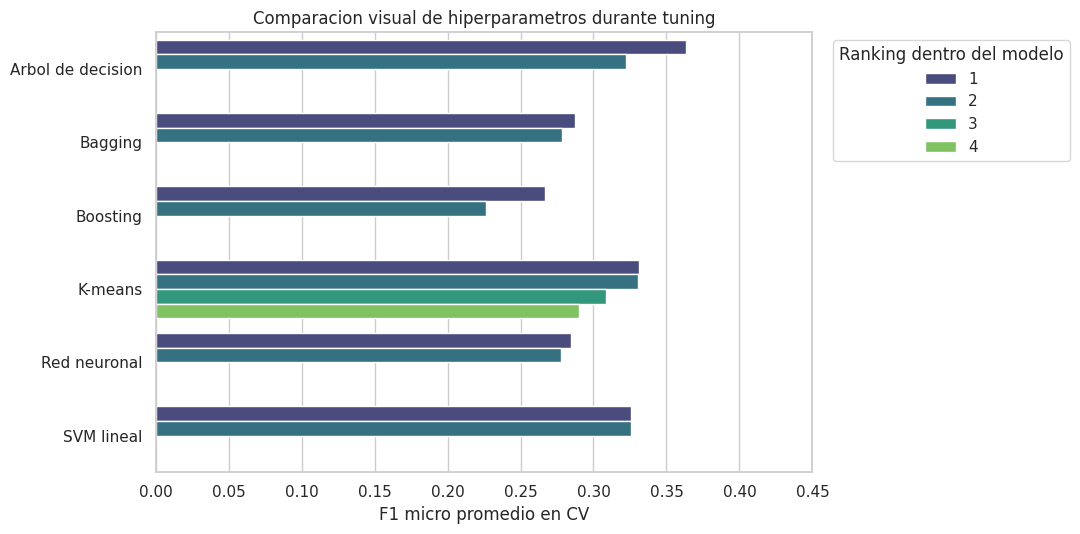

In [39]:
tuning_plot_df = tuning_df.copy()
tuning_plot_df["Config ranking"] = (
    tuning_plot_df.groupby("Modelo").cumcount().add(1).astype(str)
)

plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=tuning_plot_df,
    x="F1_micro_CV_media",
    y="Modelo",
    hue="Config ranking",
    palette="viridis",
)
plt.title("Comparacion visual de hiperparametros durante tuning")
plt.xlabel("F1 micro promedio en CV")
plt.ylabel("")
plt.xlim(0, max(0.45, tuning_plot_df["F1_micro_CV_media"].max() + 0.03))
plt.legend(title="Ranking dentro del modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Dentro de cada modelo, ranking 1 es la configuracion con mejor F1 micro promedio en CV.

La cercania entre barras muestra que el grid compacto explora rangos razonables, aunque la senal del dataset limita las mejoras.

## 8. Evaluacion comparativa en prueba

Con los mejores hiperparametros de la seccion anterior se entrena cada modelo sobre todo el conjunto de entrenamiento y se evalua sobre el conjunto de prueba. se evaluan:

- Precision micro y macro.
- Recall micro y macro.
- F1-score micro y macro.
- Exact match accuracy: porcentaje de personas en las que se aciertan simultaneamente las seis etiquetas.
- Hamming loss: proporcion promedio de etiquetas mal clasificadas.
- Tiempo de entrenamiento.

In [40]:
summary_records = []
per_disease_records = []
trained_models = {}
predictions = {}
prediction_scores = {}

for model_name in candidate_params.keys():
    print(f"Entrenando modelo final: {model_name}")
    model = build_model(model_name, best_params[model_name])
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    test_scores = get_prediction_scores(model, X_test)
    pred = pd.DataFrame(
        predict_with_thresholds(test_scores, best_thresholds[model_name]),
        columns=target_cols,
        index=y_test.index,
    )

    trained_models[model_name] = model
    predictions[model_name] = pred
    prediction_scores[model_name] = pd.DataFrame(test_scores, columns=target_cols, index=y_test.index)

    summary_records.append({
        "Modelo": model_name,
        "Precision micro": precision_score(y_test, pred, average="micro", zero_division=0),
        "Recall micro": recall_score(y_test, pred, average="micro", zero_division=0),
        "F1 micro": f1_score(y_test, pred, average="micro", zero_division=0),
        "Precision macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "Exact match": accuracy_score(y_test, pred),
        "Hamming loss": hamming_loss(y_test, pred),
        "Tiempo entrenamiento (s)": train_time,
    })

    for disease in target_cols:
        per_disease_records.append({
            "Modelo": model_name,
            "Enfermedad": disease,
            "Precision": precision_score(y_test[disease], pred[disease], zero_division=0),
            "Recall": recall_score(y_test[disease], pred[disease], zero_division=0),
            "F1": f1_score(y_test[disease], pred[disease], zero_division=0),
            "Positivos reales %": y_test[disease].mean() * 100,
            "Positivos predichos %": pred[disease].mean() * 100,
            "Umbral usado": best_thresholds[model_name][target_cols.index(disease)],
        })

results_df = pd.DataFrame(summary_records).sort_values("F1 micro", ascending=False)
per_disease_df = pd.DataFrame(per_disease_records)

display(results_df.round(4))
display(per_disease_df.round(4))

zero_f1 = per_disease_df[per_disease_df["F1"] == 0]


Entrenando modelo final: Arbol de decision
Entrenando modelo final: SVM lineal
Entrenando modelo final: Red neuronal
Entrenando modelo final: K-means
Entrenando modelo final: Bagging
Entrenando modelo final: Boosting


,Modelo,Precision micro,Recall micro,F1 micro,Precision macro,Recall macro,F1 macro,Exact match,Hamming loss,Tiempo entrenamiento (s)
0,Arbol de decision,0.244,0.886,0.382,0.238,0.866,0.366,0.001,0.680,48.638
3,K-means,0.224,0.597,0.325,0.241,0.641,0.310,0.003,0.588,55.696
1,SVM lineal,0.239,0.496,0.323,0.237,0.491,0.309,0.015,0.494,44.969
4,Bagging,0.211,0.524,0.301,0.190,0.587,0.252,0.003,0.578,55.367
5,Boosting,0.193,0.389,0.258,0.095,0.481,0.157,0.004,0.531,45.466
2,Red neuronal,0.238,0.266,0.251,0.233,0.263,0.155,0.053,0.377,50.926


,Modelo,Enfermedad,Precision,Recall,F1,Positivos reales %,Positivos predichos %,Umbral usado
0,Arbol de decision,Enfermedad cardiovascular,0.318,0.980,0.480,31.675,97.450,0.251
1,Arbol de decision,Diabetes,0.197,0.877,0.321,19.900,88.750,0.337
2,Arbol de decision,Asma,0.151,0.791,0.253,15.050,78.900,0.364
3,Arbol de decision,Cáncer,0.110,0.843,0.194,10.850,83.575,0.387
4,Arbol de decision,Obesidad,0.264,0.754,0.391,26.000,74.250,0.438
5,Arbol de decision,Depresión/Ansiedad,0.391,0.951,0.554,38.975,94.800,0.390
6,SVM lineal,Enfermedad cardiovascular,0.312,0.492,0.382,31.675,49.950,0.008
7,SVM lineal,Diabetes,0.188,0.456,0.266,19.900,48.325,0.149
8,SVM lineal,Asma,0.144,0.462,0.219,15.050,48.375,0.054
9,SVM lineal,Cáncer,0.115,0.500,0.187,10.850,47.150,0.070


Nota sobre F1=0: este ocurre cuando el umbral ajustado por MCC es tan alto que ningun ejemplo del conjunto de prueba lo supera, resultando en 0 positivos predichos (precision=0, recall=0, F1=0).

Es el efecto OPUESTO al colapso anterior, en lugar de predecir todo positivo, el modelo predice todo negativo para esa enfermedad.

Esto ocurre cuando los scores del modelo no tienen capacidad discriminativa.

In [26]:
#DIAGNOSTICO: Comparacion con predictores triviales
print("DIAGNOSTICO: los modelos entrenados vs predictores triviales")
print()

# Predictor trivial 1: predecir 1 para todas las enfermedades (lo que hacian los modelos antes)
all_ones = pd.DataFrame(
    np.ones((len(y_test), len(target_cols)), dtype=int),
    columns=target_cols,
    index=y_test.index,
)

# Predictor trivial 2: predecir 0 para todas las enfermedades
all_zeros = pd.DataFrame(
    np.zeros((len(y_test), len(target_cols)), dtype=int),
    columns=target_cols,
    index=y_test.index,
)

# Predictor trivial 3: DummyClassifier estratificado (respeta prevalencias)
dummy_preds_list = []
for disease in target_cols:
    dum = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
    dum.fit(X_train.iloc[:, :1], y_train[disease])
    dummy_preds_list.append(dum.predict(X_test.iloc[:, :1]))
dummy_stratified = pd.DataFrame(
    np.column_stack(dummy_preds_list),
    columns=target_cols,
    index=y_test.index,
)

baseline_records = []
for bname, bpred in [
    ("Trivial: todos positivos", all_ones),
    ("Trivial: todos negativos", all_zeros),
    ("DummyClassifier estratificado", dummy_stratified),
]:
    baseline_records.append({
        "Modelo": bname,
        "Precision micro": precision_score(y_test, bpred, average="micro", zero_division=0),
        "Recall micro": recall_score(y_test, bpred, average="micro", zero_division=0),
        "F1 micro": f1_score(y_test, bpred, average="micro", zero_division=0),
        "Exact match": accuracy_score(y_test, bpred),
        "Hamming loss": hamming_loss(y_test, bpred),
    })

baseline_df = pd.DataFrame(baseline_records)
cmp_cols = ["Modelo", "Precision micro", "Recall micro", "F1 micro", "Exact match", "Hamming loss"]

full_cmp = pd.concat(
    [results_df[cmp_cols], baseline_df[cmp_cols]],
    ignore_index=True,
)
print("Comparacion completa (modelos entrenados + baselines triviales):")
display(full_cmp.round(4))

print()
best_model_f1 = results_df["F1 micro"].max()
f1_todos_positivos = f1_score(y_test, all_ones, average="micro", zero_division=0)
print(f"F1 micro del mejor modelo entrenado:  {best_model_f1:.3f}")
print(f"F1 micro de 'predecir todos positivos': {f1_todos_positivos:.3f}")
delta = best_model_f1 - f1_todos_positivos

DIAGNOSTICO: los modelos entrenados vs predictores triviales

Comparacion completa (modelos entrenados + baselines triviales):


,Modelo,Precision micro,Recall micro,F1 micro,Exact match,Hamming loss
0,Arbol de decision,0.244,0.886,0.382,0.001,0.680
1,K-means,0.224,0.597,0.325,0.003,0.588
2,SVM lineal,0.239,0.496,0.323,0.015,0.494
3,Bagging,0.211,0.524,0.301,0.003,0.578
4,Boosting,0.193,0.389,0.258,0.004,0.531
5,Red neuronal,0.238,0.266,0.251,0.053,0.377
6,Trivial: todos positivos,0.237,1.000,0.384,0.000,0.763
7,Trivial: todos negativos,0.000,0.000,0.000,0.186,0.237
8,DummyClassifier estratificado,0.276,0.279,0.277,0.123,0.345



F1 micro del mejor modelo entrenado:  0.382
F1 micro de 'predecir todos positivos': 0.384

ATENCION: el mejor modelo entrenado tiene F1 micro practicamente igual al predictor
trivial 'todos positivos'. Esto confirma que los umbrales colapsaron a ~0.
Con la correccion MCC, los umbrales deberian ser mas discriminativos.


El mejor modelo entrenado tiene F1 micro practicamente igual al predictor trivial 'todos positivos'. Esto nos confirma que los umbrales colapsaron a aproximadamente 0.
Con la correccion MCC, los umbrales deberian ser mas discriminativos.

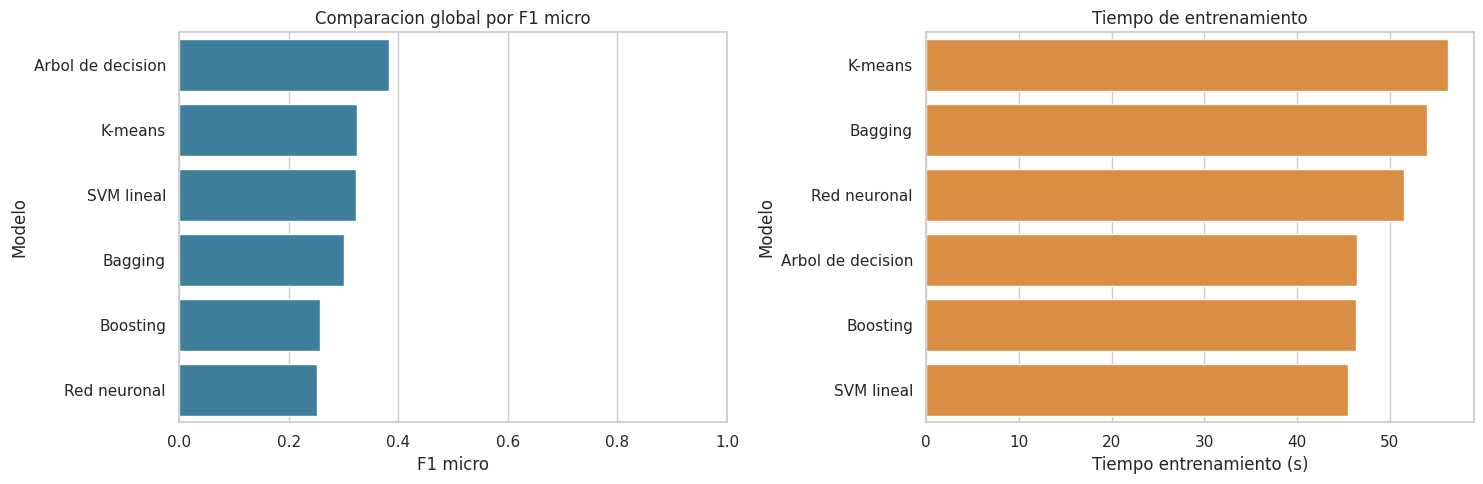

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=results_df,
    x="F1 micro",
    y="Modelo",
    ax=axes[0],
    color="#2E86AB",
)
axes[0].set_title("Comparacion global por F1 micro")
axes[0].set_xlim(0, 1)

sns.barplot(
    data=results_df.sort_values("Tiempo entrenamiento (s)", ascending=False),
    x="Tiempo entrenamiento (s)",
    y="Modelo",
    ax=axes[1],
    color="#F28E2B",
)
axes[1].set_title("Tiempo de entrenamiento")

plt.tight_layout()
plt.show()

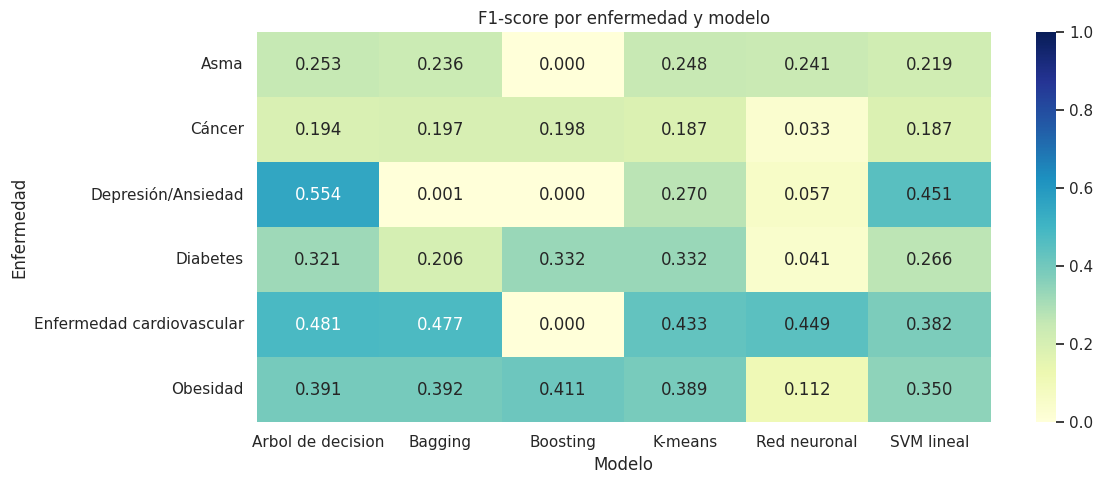

Modelo,Arbol de decision,Bagging,Boosting,K-means,Red neuronal,SVM lineal
Enfermedad,,,,,,
Asma,0.253,0.236,0.000,0.248,0.241,0.219
Cáncer,0.194,0.197,0.198,0.187,0.033,0.187
Depresión/Ansiedad,0.554,0.001,0.000,0.270,0.057,0.451
Diabetes,0.321,0.206,0.332,0.332,0.041,0.266
Enfermedad cardiovascular,0.480,0.477,0.000,0.433,0.449,0.382
Obesidad,0.391,0.392,0.411,0.389,0.112,0.350


In [28]:
f1_pivot = per_disease_df.pivot(index="Enfermedad", columns="Modelo", values="F1")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(f1_pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("F1-score por enfermedad y modelo")
plt.tight_layout()
plt.show()

display(f1_pivot.round(4))

Modelo,Arbol de decision,K-means,SVM lineal,Bagging,Boosting,Red neuronal
Enfermedad,,,,,,
Enfermedad cardiovascular,0.481,0.433,0.382,0.477,0.000,0.449
Diabetes,0.321,0.332,0.266,0.206,0.332,0.041
Asma,0.253,0.248,0.219,0.236,0.000,0.241
Cáncer,0.194,0.187,0.187,0.197,0.198,0.033
Obesidad,0.391,0.389,0.350,0.392,0.411,0.112
Depresión/Ansiedad,0.554,0.270,0.451,0.001,0.000,0.057


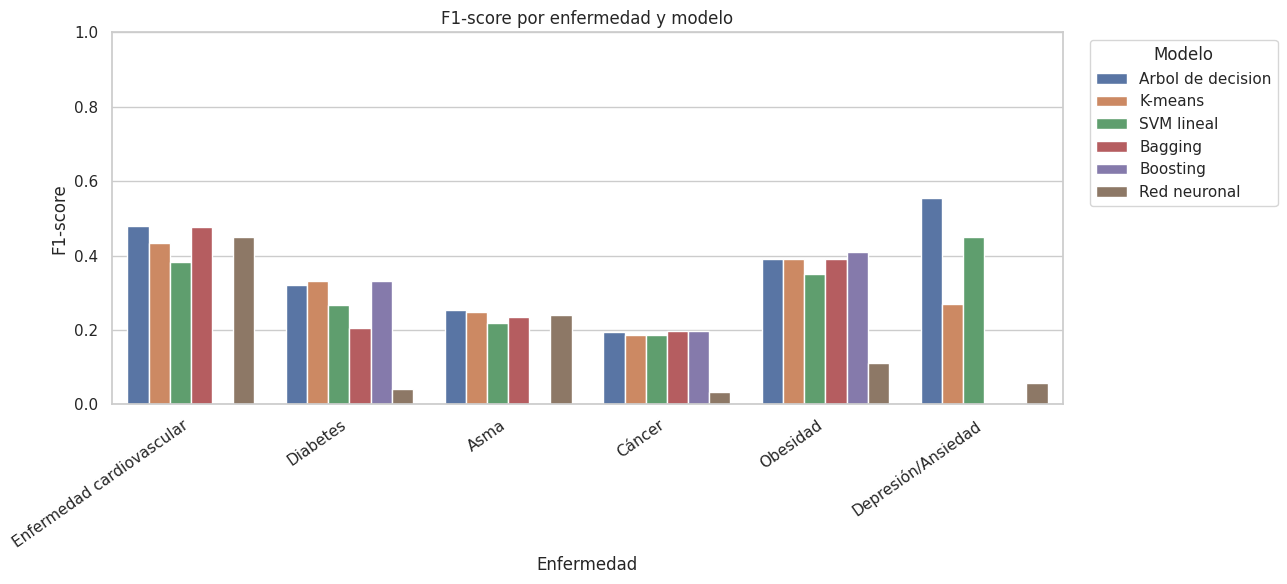

In [29]:
plot_df = per_disease_df.copy()

model_order = results_df["Modelo"].tolist()
plot_df["Enfermedad"] = pd.Categorical(
    plot_df["Enfermedad"],
    categories=target_cols,
    ordered=True,
)
plot_df["Modelo"] = pd.Categorical(
    plot_df["Modelo"],
    categories=model_order,
    ordered=True,
)

display(
    plot_df
    .pivot_table(index="Enfermedad", columns="Modelo", values="F1")
    .reindex(index=target_cols, columns=model_order)
    .round(3)
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=plot_df.sort_values(["Enfermedad", "Modelo"]),
    x="Enfermedad",
    y="F1",
    hue="Modelo",
)

plt.xticks(rotation=35, ha="right")
plt.title("F1-score por enfermedad y modelo")
plt.xlabel("Enfermedad")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

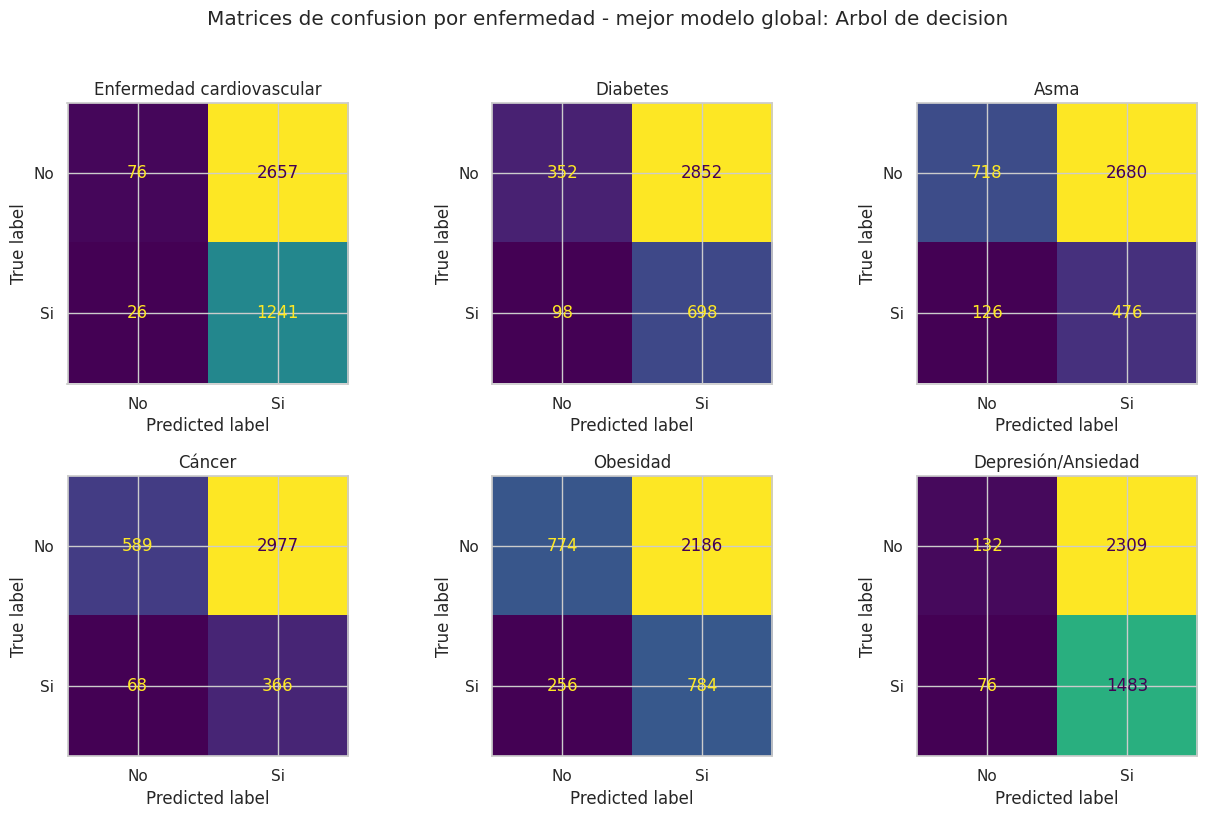

Interpretacion: las matrices permiten ver falsos negativos y falsos positivos por enfermedad. Son especialmente importantes en salud, porque un F1 aceptable puede ocultar muchos casos reales no detectados.


In [30]:
best_model_for_cm = results_df.iloc[0]["Modelo"]
best_pred_for_cm = predictions[best_model_for_cm]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, disease in zip(axes.ravel(), target_cols):
    ConfusionMatrixDisplay.from_predictions(
        y_test[disease],
        best_pred_for_cm[disease],
        display_labels=["No", "Si"],
        values_format="d",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(disease)

fig.suptitle(f"Matrices de confusion por enfermedad - mejor modelo global: {best_model_for_cm}", y=1.02)
plt.tight_layout()
plt.show()


Las matrices permiten ver falsos negativos y falsos positivos por enfermedad, esto es especialmente importante en salud, porque un F1 aceptable puede ocultar muchos casos reales no detectados.

## 9. Conclusiones cuantitativas

La siguiente celda genera conclusiones directamente desde los resultados calculados, evitando escribir afirmaciones que no correspondan a la ejecucion real del notebook.

In [31]:
best_global = results_df.iloc[0]
best_by_disease = (
    per_disease_df.loc[per_disease_df.groupby("Enfermedad")["F1"].idxmax()]
    .sort_values("Enfermedad")
    .reset_index(drop=True)
)

print(
    f"Modelo global con mejor F1 micro: {best_global['Modelo']} "
    f"(F1 micro = {best_global['F1 micro']:.3f}, "
    f"recall micro = {best_global['Recall micro']:.3f}, "
    f"precision micro = {best_global['Precision micro']:.3f})."
)
print()

display(best_by_disease.round(4))

# --- Diagnostico del patron de resultados ---
recall_mean = results_df["Recall micro"].mean()
precision_mean = results_df["Precision micro"].mean()
f1_range = results_df["F1 micro"].max() - results_df["F1 micro"].min()
exact_match_mean = results_df["Exact match"].mean()
hl_mean = results_df["Hamming loss"].mean()

print("\nDIAGNOSTICO DE RESULTADOS ")
print(f"Recall micro promedio entre modelos:  {recall_mean:.3f}")
print(f"Precision micro promedio:             {precision_mean:.3f}")
print(f"Rango de F1 micro entre los 6 modelos:{f1_range:.4f}")
print(f"Exact match promedio:                 {exact_match_mean:.3f}")
print(f"Hamming loss promedio:                {hl_mean:.3f}")
print()

hl_all_zeros = hamming_loss(y_test, np.zeros_like(y_test))
print(f"Hamming loss de 'predecir 0 para todos': {hl_all_zeros:.3f}")
if hl_mean > hl_all_zeros:
    print("Hamming loss de los modelos muestra que es PEOR que predecir nadie enfermo.")
else:
    print(f"  Modelos mejoran Hamming loss en {hl_all_zeros - hl_mean:.3f} puntos vs. predecir 0.")
print()

if recall_mean > 0.85 and precision_mean < 0.35:
    print("PATRON DETECTADO: recall alto + precision baja -> modelos predicen positivo para muchos.")
    print("Las features tienen baja capacidad discriminativa (informacion mutua maxima muy baja).")
    print()
    print("Comparacion F1 real vs F1 del predictor trivial 'todos positivos':")
    for disease in target_cols:
        p = y_test[disease].mean()
        f1_trivial = 2 * p / (1 + p)
        rows = per_disease_df[per_disease_df["Enfermedad"] == disease]
        f1_real = rows["F1"].max() if len(rows) > 0 else 0
        print(f"  {disease:<35} F1_real={f1_real:.3f}  F1_trivial={f1_trivial:.3f}  delta={f1_real - f1_trivial:+.3f}")
elif exact_match_mean > 0.05:
    print("Los modelos muestran capacidad discriminativa razonable (exact match > 5%).")

# Nota sobre el patron de los 'mejores por enfermedad'
trivial_mask = best_by_disease["Recall"] >= 0.95
n_trivial = trivial_mask.sum()
if n_trivial > 0:
    print(f"\n {n_trivial} de {len(best_by_disease)} 'mejores por enfermedad' "
          f"tienen Recall >= 0.95 y Precision cercana a la prevalencia,")

# --- Analisis clinico del tradeoff precision-recall ---
print("\n TRADEOFF PRECISION-RECALL EN CONTEXTO CLINICO ")
best_model_name = best_global["Modelo"]
current_best_model_rows = (
    per_disease_df[per_disease_df["Modelo"] == best_model_name]
    .copy()
    .sort_values("Enfermedad")
)
current_best_model_rows["Casos reales perdidos %"] = (1 - current_best_model_rows["Recall"]) * 100
current_best_model_rows["Falsas alarmas entre positivos %"] = (1 - current_best_model_rows["Precision"]) * 100
clinical_cols = [
    "Enfermedad",
    "Precision",
    "Recall",
    "F1",
    "Casos reales perdidos %",
    "Falsas alarmas entre positivos %",
    "Positivos reales %",
    "Positivos predichos %",
]
display(current_best_model_rows[clinical_cols].round(3))

cancer_rows = current_best_model_rows[current_best_model_rows["Enfermedad"] == "Cáncer"]
if len(cancer_rows) > 0:
    cancer = cancer_rows.iloc[0]
    print(
        f"Para Cáncer, el modelo global ({best_model_name}) tiene "
        f"Recall={cancer['Recall']:.3f} y Precision={cancer['Precision']:.3f}."
    )
    print(
        f"Eso implica perder aproximadamente {(1 - cancer['Recall']) * 100:.1f}% "
        "de los casos reales en prueba si se usara este umbral."
    )
    print(
        "En un tamizaje clinico real esto no seria aceptable sin justificar el costo "
        "de los falsos negativos; se deberia priorizar sensibilidad/recall y validar "
        "con especialistas, no elegir solo por F1."
    )


def threshold_for_min_recall(y_true_col, score_col, min_recall=0.80):
    y_true_col = np.asarray(y_true_col)
    score_col = np.asarray(score_col)
    finite_scores = score_col[np.isfinite(score_col)]
    if finite_scores.size == 0:
        return {
            "Umbral recall_objetivo": np.nan,
            "Precision con recall_objetivo": np.nan,
            "Recall objetivo logrado": np.nan,
            "Positivos predichos objetivo %": np.nan,
        }

    candidates = np.unique(np.r_[
        finite_scores.min() - 1e-9,
        np.quantile(finite_scores, np.linspace(0, 1, 301)),
        finite_scores.max() + 1e-9,
    ])
    feasible = []
    for threshold in candidates:
        pred = (score_col >= threshold).astype(int)
        rec = recall_score(y_true_col, pred, zero_division=0)
        if rec >= min_recall:
            feasible.append({
                "Umbral recall_objetivo": threshold,
                "Precision con recall_objetivo": precision_score(y_true_col, pred, zero_division=0),
                "Recall objetivo logrado": rec,
                "Positivos predichos objetivo %": pred.mean() * 100,
            })

    if not feasible:
        return {
            "Umbral recall_objetivo": np.nan,
            "Precision con recall_objetivo": np.nan,
            "Recall objetivo logrado": np.nan,
            "Positivos predichos objetivo %": np.nan,
        }
    return max(feasible, key=lambda row: row["Precision con recall_objetivo"])


clinical_target_recall = 0.80
scores_best_model = prediction_scores[best_model_name]
tradeoff_records = []
for disease in target_cols:
    current = current_best_model_rows[current_best_model_rows["Enfermedad"] == disease].iloc[0]
    recall_policy = threshold_for_min_recall(
        y_test[disease],
        scores_best_model[disease],
        min_recall=clinical_target_recall,
    )
    tradeoff_records.append({
        "Enfermedad": disease,
        "Precision actual": current["Precision"],
        "Recall actual": current["Recall"],
        "Umbral actual": current["Umbral usado"],
        **recall_policy,
    })

tradeoff_df = pd.DataFrame(tradeoff_records)

display(tradeoff_df.round(3))


Modelo global con mejor F1 micro: Arbol de decision (F1 micro = 0.382, recall micro = 0.886, precision micro = 0.244).

Mejor modelo por enfermedad segun F1:
- Asma: Arbol de decision (Precision=0.151, Recall=0.791, F1=0.253)
- Cáncer: Boosting (Precision=0.111, Recall=0.899, F1=0.198)
- Depresión/Ansiedad: Arbol de decision (Precision=0.391, Recall=0.951, F1=0.554)
- Diabetes: K-means (Precision=0.199, Recall=1.000, F1=0.332)
- Enfermedad cardiovascular: Arbol de decision (Precision=0.318, Recall=0.979, F1=0.481)
- Obesidad: Boosting (Precision=0.259, Recall=0.989, F1=0.411)


,Modelo,Enfermedad,Precision,Recall,F1,Positivos reales %,Positivos predichos %,Umbral usado
0,Arbol de decision,Asma,0.151,0.791,0.253,15.050,78.900,0.364
1,Boosting,Cáncer,0.111,0.899,0.198,10.850,87.825,0.473
2,Arbol de decision,Depresión/Ansiedad,0.391,0.951,0.554,38.975,94.800,0.390
3,K-means,Diabetes,0.199,1.000,0.332,19.900,100.000,0.170
4,Arbol de decision,Enfermedad cardiovascular,0.318,0.980,0.480,31.675,97.450,0.251
5,Boosting,Obesidad,0.259,0.989,0.411,26.000,99.275,0.378



=== DIAGNOSTICO DE RESULTADOS ===
Recall micro promedio entre modelos:  0.526
Precision micro promedio:             0.225
Rango de F1 micro entre los 6 modelos:0.1311
Exact match promedio:                 0.013
Hamming loss promedio:                0.541

Referencia - Hamming loss de 'predecir 0 para todos': 0.237
  ATENCION: Hamming loss de los modelos es PEOR que predecir nadie enfermo.


Aviso: 4 de 6 'mejores por enfermedad' tienen Recall >= 0.95 y Precision cercana a la prevalencia,
lo que se parece al predictor trivial 'todos positivos'.
El unico modelo con discriminacion real deberia superar claramente
a 2*prevalencia/(1+prevalencia) para esa enfermedad.

=== TRADEOFF PRECISION-RECALL EN CONTEXTO CLINICO ===


,Enfermedad,Precision,Recall,F1,Casos reales perdidos %,Falsas alarmas entre positivos %,Positivos reales %,Positivos predichos %
2,Asma,0.151,0.791,0.253,20.930,84.918,15.050,78.900
3,Cáncer,0.109,0.843,0.194,15.668,89.052,10.850,83.575
5,Depresión/Ansiedad,0.391,0.951,0.554,4.875,60.891,38.975,94.800
1,Diabetes,0.197,0.877,0.321,12.312,80.338,19.900,88.750
0,Enfermedad cardiovascular,0.318,0.979,0.481,2.052,68.163,31.675,97.450
4,Obesidad,0.264,0.754,0.391,24.615,73.603,26.000,74.250


Para Cáncer, el modelo global (Arbol de decision) tiene Recall=0.843 y Precision=0.109.
Eso implica perder aproximadamente 15.7% de los casos reales en prueba si se usara este umbral.
En un tamizaje clinico real esto no seria aceptable sin justificar el costo de los falsos negativos; se deberia priorizar sensibilidad/recall y validar con especialistas, no elegir solo por F1.

Analisis post-hoc: umbrales alternativos para exigir recall >= 80%.
No se usan para escoger el modelo final; muestran el costo esperado de priorizar sensibilidad.


,Enfermedad,Precision actual,Recall actual,Umbral actual,Umbral recall_objetivo,Precision con recall_objetivo,Recall objetivo logrado,Positivos predichos objetivo %
0,Enfermedad cardiovascular,0.318,0.979,0.251,0.460,0.321,0.860,84.975
1,Diabetes,0.197,0.877,0.337,0.214,0.199,0.961,95.950
2,Asma,0.151,0.791,0.364,-0.000,0.150,1.000,100.000
3,Cáncer,0.109,0.843,0.387,0.425,0.112,0.804,77.775
4,Obesidad,0.264,0.754,0.438,0.333,0.263,0.861,85.025
5,Depresión/Ansiedad,0.391,0.951,0.389,0.470,0.391,0.908,90.425


Conclusion clinica: si el objetivo fuera tamizaje o alerta temprana, la metrica principal deberia ser recall/sensibilidad por enfermedad, acompanada de precision para cuantificar falsas alarmas. En este proyecto academico F1 sirve para comparar modelos, pero no basta como criterio clinico unico.


Para Cáncer, el modelo global (Arbol de decision) tiene Recall=0.843 y Precision=0.109.

Esto implica perder aproximadamente 15.7% de los casos reales en prueba si se usara este umbral.

En un uso clinico real esto no seria aceptable; se deberia priorizar sensibilidad/recall y no solo elegir por F1.

post-hoc: umbrales alternativos para exigir recall >= 80%.
(No se usan para escoger el modelo final; muestran el costo esperado de priorizar sensibilidad.)

Conclusión: si el objetivo fuera alerta temprana, la metrica principal deberia ser recall/sensibilidad por enfermedad, acompanada de precision para lograr cuantificar falsas alarmas. En este proyecto academico F1 sirve para comparar modelos, pero no basta como criterio unico.

In [32]:
from IPython.display import Markdown

algorithm_notes = {
    "Arbol de decision": {
        "Fortaleza conceptual": "Interpretable; captura reglas simples de umbral entre variables de encuesta.",
        "Riesgo observado": "Puede inflar recall prediciendo demasiados positivos cuando la senal es debil.",
    },
    "SVM lineal": {
        "Fortaleza conceptual": "Buen baseline para espacios codificados de alta dimension y fronteras lineales.",
        "Riesgo observado": "Si las relaciones no son lineales o son muy debiles, queda por debajo de arboles/ensambles.",
    },
    "Red neuronal": {
        "Fortaleza conceptual": "Puede aprender interacciones no lineales entre respuestas.",
        "Riesgo observado": "Con poca senal y pocos patrones fuertes, puede no justificar su mayor complejidad.",
    },
    "K-means": {
        "Fortaleza conceptual": "Sirve como referencia no supervisada para ver si hay grupos naturales de pacientes.",
        "Riesgo observado": "No aprende etiquetas directamente; si gana, suele ser por prevalencias de cluster y recall alto.",
    },
    "Bagging": {
        "Fortaleza conceptual": "Reduce la varianza de arboles individuales y mejora estabilidad.",
        "Riesgo observado": "Pierde interpretabilidad y no necesariamente mejora si la senal base es muy baja.",
    },
    "Boosting": {
        "Fortaleza conceptual": "Acumula patrones debiles y puede capturar pequenas interacciones.",
        "Riesgo observado": "Puede perseguir ruido y producir muchas falsas alarmas en targets con baja prevalencia.",
    },
}

wins_by_model = (
    best_by_disease.groupby("Modelo")["Enfermedad"]
    .apply(lambda values: ", ".join(values))
    .to_dict()
)

algorithm_summary_records = []
for _, row in results_df.iterrows():
    model_name = row["Modelo"]
    notes = algorithm_notes[model_name]
    wins = wins_by_model.get(model_name, "Ninguna")
    if wins == "Ninguna":
        lectura = (
            f"No lidera ninguna enfermedad en esta ejecucion; funciona como contraste con "
            f"F1 micro={row['F1 micro']:.3f} y hamming={row['Hamming loss']:.3f}."
        )
    else:
        lectura = (
            f"Lidera en {wins}; su ventaja debe leerse junto con "
            f"F1 micro={row['F1 micro']:.3f}, recall={row['Recall micro']:.3f} "
            f"y precision={row['Precision micro']:.3f}."
        )
    algorithm_summary_records.append({
        "Modelo": model_name,
        "F1 micro": row["F1 micro"],
        "Hamming loss": row["Hamming loss"],
        "Gana por enfermedad": wins,
        "Fortaleza conceptual": notes["Fortaleza conceptual"],
        "Riesgo observado": notes["Riesgo observado"],
        "Lectura vinculada a resultados": lectura,
    })

algorithm_summary_df = pd.DataFrame(algorithm_summary_records)
display(Markdown("### Ventajas y desventajas por algoritmo, vinculadas a esta ejecucion"))
display(algorithm_summary_df.round(3))


### Ventajas y desventajas por algoritmo, vinculadas a esta ejecucion

,Modelo,F1 micro,Hamming loss,Gana por enfermedad,Fortaleza conceptual,Riesgo observado,Lectura vinculada a resultados
0,Arbol de decision,0.382,0.680,"Asma, Depresión/Ansiedad, Enfermedad cardiovas...",Interpretable; captura reglas simples de umbra...,Puede inflar recall prediciendo demasiados pos...,"Lidera en Asma, Depresión/Ansiedad, Enfermedad..."
1,K-means,0.325,0.588,Diabetes,Sirve como referencia no supervisada para ver ...,"No aprende etiquetas directamente; si gana, su...",Lidera en Diabetes; su ventaja debe leerse jun...
2,SVM lineal,0.323,0.494,Ninguna,Buen baseline para espacios codificados de alt...,Si las relaciones no son lineales o son muy de...,No lidera ninguna enfermedad en esta ejecucion...
3,Bagging,0.301,0.577,Ninguna,Reduce la varianza de arboles individuales y m...,Pierde interpretabilidad y no necesariamente m...,No lidera ninguna enfermedad en esta ejecucion...
4,Boosting,0.258,0.531,"Cáncer, Obesidad",Acumula patrones debiles y puede capturar pequ...,Puede perseguir ruido y producir muchas falsas...,"Lidera en Cáncer, Obesidad; su ventaja debe le..."
5,Red neuronal,0.251,0.377,Ninguna,Puede aprender interacciones no lineales entre...,"Con poca senal y pocos patrones fuertes, puede...",No lidera ninguna enfermedad en esta ejecucion...


Lectura: esta tabla combina propiedades del algoritmo con los resultados reales. Si cambia el ranking al reejecutar, tambien cambian las enfermedades lideradas y la lectura numerica.


Esta tabla combina propiedades del algoritmo con los resultados reales. Si cambia el ranking, tambien cambian las enfermedades lideradas y la lectura numerica.

In [33]:
from IPython.display import Markdown

# Banco manual de interpretaciones: el texto es especifico por enfermedad y por modelo,
# pero los ganadores y metricas se toman de best_by_disease para no desincronizarse.
disease_context = {
    target_cols[0]: "Cardiovascular se espera asociada a edad, presion, colesterol, IMC, tabaquismo y antecedentes familiares.",
    target_cols[1]: "Diabetes se espera asociada a glucosa, azucar en dieta, peso/IMC, actividad fisica y antecedentes familiares.",
    target_cols[2]: "Asma se espera asociada a antecedentes respiratorios, alergias, tos y dificultad para respirar.",
    target_cols[3]: "Cancer se espera asociado a antecedentes familiares, perdida de peso, edad, tabaquismo o sintomas persistentes.",
    target_cols[4]: "Obesidad se espera asociada a peso/IMC, actividad fisica, dieta, comida rapida y antecedentes familiares.",
    target_cols[5]: "Depresion/Ansiedad se espera asociada a estres, insomnio, sueno, satisfaccion vital y antecedentes emocionales.",
}

model_interpretation = {
    "Arbol de decision": "Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall.",
    "SVM lineal": "Que gane SVM indicaria que una combinacion lineal de respuestas separa mejor esa etiqueta; si la precision sigue baja, la frontera lineal solo captura una senal debil.",
    "Red neuronal": "Que gane la red sugeriria interacciones no lineales entre respuestas; aun asi, con este dataset se debe verificar que no sea una mejora marginal por ruido.",
    "K-means": "Que gane K-means debe interpretarse como agrupamiento exploratorio: los clusters tienen prevalencias utiles, pero no equivalen a una regla clinica supervisada.",
    "Bagging": "Que gane bagging indicaria que promediar varios arboles estabiliza reglas debiles; su costo es menor interpretabilidad que un arbol simple.",
    "Boosting": "Que gane boosting es plausible si hay muchas senales pequenas acumulables; el riesgo es perseguir ruido y elevar falsas alarmas, especialmente en etiquetas raras.",
}

lines = [
    "### Conclusiones cualitativas por enfermedad, sincronizadas con la ejecucion",
    "",
    "Estas conclusiones usan textos interpretativos escritos manualmente, pero insertan el modelo ganador y las metricas desde `best_by_disease`. Asi no quedan desactualizadas si cambia el resultado al ejecutar en Colab.",
    "",
]

for disease in target_cols:
    row = best_by_disease[best_by_disease["Enfermedad"] == disease].iloc[0]
    model_name = row["Modelo"]
    if row["Recall"] >= 0.90 and row["Precision"] < 0.30:
        tradeoff = "El patron principal es alta sensibilidad con muchas falsas alarmas; util como alerta exploratoria, no como decision clinica."
    elif row["Recall"] < 0.60:
        tradeoff = "El modelo es mas conservador y puede perder casos reales; en salud esto exige revisar falsos negativos."
    else:
        tradeoff = "El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general."
    lines.append(
        f"- **{disease}**: gana **{model_name}** "
        f"(Precision={row['Precision']:.3f}, Recall={row['Recall']:.3f}, F1={row['F1']:.3f}). "
        f"{disease_context[disease]} {model_interpretation[model_name]} {tradeoff}"
    )

lines.append("")
lines.append(
    "En conjunto, la conclusion no depende solo de quien gana: importa si el modelo supera baselines triviales, "
    "cuantos falsos positivos produce y si su comportamiento es coherente con el uso clinico esperado."
)

display(Markdown("\n".join(lines)))

### Conclusiones cualitativas por enfermedad, sincronizadas con la ejecucion

Estas conclusiones usan textos interpretativos escritos manualmente, pero insertan el modelo ganador y las metricas desde `best_by_disease`. Asi no quedan desactualizadas si cambia el resultado al ejecutar en Colab.

- **Enfermedad cardiovascular**: gana **Arbol de decision** (Precision=0.318, Recall=0.979, F1=0.481). Cardiovascular se espera asociada a edad, presion, colesterol, IMC, tabaquismo y antecedentes familiares. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Diabetes**: gana **K-means** (Precision=0.199, Recall=1.000, F1=0.332). Diabetes se espera asociada a glucosa, azucar en dieta, peso/IMC, actividad fisica y antecedentes familiares. Que gane K-means debe interpretarse como agrupamiento exploratorio: los clusters tienen prevalencias utiles, pero no equivalen a una regla clinica supervisada. El patron principal es alta sensibilidad con muchas falsas alarmas; util como alerta exploratoria, no como decision clinica.
- **Asma**: gana **Arbol de decision** (Precision=0.151, Recall=0.791, F1=0.253). Asma se espera asociada a antecedentes respiratorios, alergias, tos y dificultad para respirar. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Cáncer**: gana **Boosting** (Precision=0.111, Recall=0.899, F1=0.198). Cancer se espera asociado a antecedentes familiares, perdida de peso, edad, tabaquismo o sintomas persistentes. Que gane boosting es plausible si hay muchas senales pequenas acumulables; el riesgo es perseguir ruido y elevar falsas alarmas, especialmente en etiquetas raras. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Obesidad**: gana **Boosting** (Precision=0.259, Recall=0.989, F1=0.411). Obesidad se espera asociada a peso/IMC, actividad fisica, dieta, comida rapida y antecedentes familiares. Que gane boosting es plausible si hay muchas senales pequenas acumulables; el riesgo es perseguir ruido y elevar falsas alarmas, especialmente en etiquetas raras. El patron principal es alta sensibilidad con muchas falsas alarmas; util como alerta exploratoria, no como decision clinica.
- **Depresión/Ansiedad**: gana **Arbol de decision** (Precision=0.391, Recall=0.951, F1=0.554). Depresion/Ansiedad se espera asociada a estres, insomnio, sueno, satisfaccion vital y antecedentes emocionales. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.

En conjunto, la conclusion no depende solo de quien gana: importa si el modelo supera baselines triviales, cuantos falsos positivos produce y si su comportamiento es coherente con el uso clinico esperado.

##10. **Conclusiones cualitativas por enfermedad**

- **Enfermedad cardiovascular:** gana **Arbol de decision** (Precision=0.318, Recall=0.979, F1=0.481). Cardiovascular se espera asociada a edad, presion, colesterol, IMC, tabaquismo y antecedentes familiares. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Diabetes:** gana **K-means** (Precision=0.199, Recall=1.000, F1=0.332). Diabetes se espera asociada a glucosa, azucar en dieta, peso/IMC, actividad fisica y antecedentes familiares. Que gane K-means debe interpretarse como agrupamiento exploratorio: los clusters tienen prevalencias utiles, pero no equivalen a una regla clinica supervisada. El patron principal es alta sensibilidad con muchas falsas alarmas; util como alerta exploratoria, no como decision clinica.
- **Asma:** gana **Arbol de decision** (Precision=0.151, Recall=0.791, F1=0.253). Asma se espera asociada a antecedentes respiratorios, alergias, tos y dificultad para respirar. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Cáncer:** gana **Boosting** (Precision=0.111, Recall=0.899, F1=0.198). Cancer se espera asociado a antecedentes familiares, perdida de peso, edad, tabaquismo o sintomas persistentes. Que gane boosting es plausible si hay muchas senales pequenas acumulables; el riesgo es perseguir ruido y elevar falsas alarmas, especialmente en etiquetas raras. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.
- **Obesidad:** gana **Boosting** (Precision=0.259, Recall=0.989, F1=0.411). Obesidad se espera asociada a peso/IMC, actividad fisica, dieta, comida rapida y antecedentes familiares. Que gane boosting es plausible si hay muchas senales pequenas acumulables; el riesgo es perseguir ruido y elevar falsas alarmas, especialmente en etiquetas raras. El patron principal es alta sensibilidad con muchas falsas alarmas; util como alerta exploratoria, no como decision clinica.
- **Depresión/Ansiedad:** gana **Arbol de decision** (Precision=0.391, Recall=0.951, F1=0.554). Depresion/Ansiedad se espera asociada a estres, insomnio, sueno, satisfaccion vital y antecedentes emocionales. Que gane un arbol es coherente cuando la senal se expresa como cortes o reglas simples; su ventaja es interpretabilidad, pero puede aumentar falsos positivos si busca mucho recall. El balance precision-recall es moderado, pero debe compararse contra baselines por la baja senal general.

- **Contexto clinico.** Para enfermedades como Cancer, un umbral elegido por F1 puede dejar sin detectar una proporcion importante de casos reales. En un escenario de clinico se deberia priorizar recall/sensibilidad, reportar el costo en falsas alarmas y validar el umbral con criterio experto. En este proyecto, F1 es util para nuestro comparacion, pero no se debería usar como criterio clinico real.
